# Progetto MIGA 2025/2026 — Sistema di Raccomandazione e Sentiment Analysis
## Notebook unico — Dataset Amazon Reviews 2023, categoria Movies_and_TV (Film & TV)

Questo notebook raccoglie l'intero progetto di **livello avanzato** in un solo file, in tre parti:

1. **Parte 1 — Progetto Base**: Collaborative Filtering (K-NN ottimale, filling, K-Means + cosine, top-N, Matrix Factorization).
2. **Parte 2 — Progetto Intermedio**: Content-Based (NLP, embedding TF-IDF e transformer, K-NN per utente, confronti critici).
3. **Parte 3 — Progetto Avanzato**: Sentiment Analysis (classificatori scikit-learn + bonus LLM).

**Come eseguire (Google Colab):** attiva la **GPU** (Runtime > Cambia tipo di runtime > T4), esegui la cella di installazione **una sola volta**, poi tutte le celle in ordine dall'alto verso il basso. La categoria si cambia nelle celle di configurazione di ciascuna parte (`CATEGORY`).

> Nota: Movies_and_TV e' enorme, quindi i dati vengono caricati **in streaming** su un campione. Le tre parti caricano i dati in modo indipendente: se vuoi puoi abbassare `MAX_REVIEWS` per andare piu veloce in fase di test.

## Installazione (eseguire una sola volta)

In [27]:
!pip -q install scikit-surprise datasets sentence-transformers transformers nltk scikit-learn pandas numpy matplotlib seaborn

---
# PARTE 1 — Progetto Base (Collaborative Filtering)

## 0. Setup ambiente

`scikit-surprise` su Colab a volte richiede una versione di NumPy compatibile: se l'import fallisce, riavvia il runtime dopo l'installazione (Runtime > Restart).

In [28]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from surprise import Dataset, Reader, KNNWithMeans, KNNBasic, SVD, accuracy
from surprise.model_selection import GridSearchCV, train_test_split, cross_validate

from sklearn.preprocessing import normalize
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

sns.set_theme(style="whitegrid")
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
print("Setup OK")

Setup OK


## Configurazione

- `CATEGORY`: categoria merceologica da analizzare (qui `Movies_and_TV`; per test piu rapidi una categoria piccola come `All_Beauty` e piu leggera).
- `MIN_USER_RATINGS` / `MIN_ITEM_RATINGS`: soglie di filtro per ridurre la sparsita e rendere il Collaborative Filtering significativo e computazionalmente trattabile (discutere questa scelta nel report: trade-off copertura vs densita / cold-start).

In [29]:
CATEGORY = "Movies_and_TV"   # categoria Film & TV
MIN_USER_RATINGS = 5         # tieni utenti con almeno N recensioni
MIN_ITEM_RATINGS = 5         # tieni item con almeno N recensioni
RATING_SCALE = (1, 5)
TOP_N = 10                   # quante raccomandazioni per utente

# Movies_and_TV e' enorme: lavoriamo su un campione in streaming per non saturare la RAM di Colab
STREAMING = True
MAX_REVIEWS = 800000         # dimensione del campione iniziale (alza se hai RAM)
# Il "core": teniamo gli utenti e gli item piu attivi per avere una matrice densa e trattabile
USERS_CAP = 3000
ITEMS_CAP = 3000

## Step 0 — Caricamento dati (solo user reviews)

Per il Progetto Base si usa **solo il file delle recensioni** (`user reviews`). Carichiamo da HuggingFace la config `raw_review_<CATEGORY>`.

In [30]:
from datasets import load_dataset

def load_reviews(category, max_rows=MAX_REVIEWS, streaming=STREAMING):
    # Le nuove versioni di datasets non eseguono lo script del repo:
    # leggiamo direttamente il file .jsonl grezzo col builder "json".
    url = f"hf://datasets/McAuley-Lab/Amazon-Reviews-2023/raw/review_categories/{category}.jsonl"
    ds = load_dataset("json", data_files=url, split="train", streaming=streaming)
    if streaming:
        ds = ds.shuffle(seed=42, buffer_size=50000)
        rows = []
        for ex in ds:
            rows.append(ex)
            if len(rows) >= max_rows:
                break
        df_ = pd.DataFrame(rows)
    else:
        df_ = ds.to_pandas()
    # nel jsonl grezzo i campi si chiamano sort_timestamp / helpful_votes
    return df_.rename(columns={"sort_timestamp": "timestamp", "helpful_votes": "helpful_vote"})

df = load_reviews(CATEGORY)
print("Shape campione:", df.shape)
df.head(3)

Shape campione: (800000, 10)


,rating,title,text,images,asin,parent_asin,user_id,timestamp,helpful_vote,verified_purchase
0,5.0,Fun MOvie,A very good car movie. Loved the humor and th...,[],B00MFDMM3I,B00MFDMM3I,AHV3V3SLT35QHQX3NQOFUDBNV2RQ,1408671919000,1,True
1,5.0,Amazing!!!,I was not prepared for the magic of this movie...,[],B0098VYCCE,B0098VYCCE,AGPFPRUBXXX65L6NCPFRYOC33JZQ,1349182789000,1,True
2,5.0,amazing,amazing and great patriotic movie. Bacon is a...,[],B009M8Q3O8,B009M8Q3O8,AGJD7SRDILE7BF3VKDRXI6B7OOPQ,1461105792000,0,True


In [31]:
# Teniamo solo le colonne utili per il CF + qualche colonna per la EDA
cols = ["rating", "title", "text", "asin", "parent_asin", "user_id",
        "timestamp", "verified_purchase", "helpful_vote"]
df = df[[c for c in cols if c in df.columns]].copy()

# Usiamo parent_asin come identificatore di item (la traccia nota che gli asin storici = parent_asin):
# in questa maniera film di versioni/edizioni diverse vengono identificati dallo stesso parent_asin
df["item_id"] = df["parent_asin"].fillna(df["asin"])
df = df.dropna(subset=["user_id", "item_id", "rating"])
df["rating"] = df["rating"].astype(float)
print("Shape pulita:", df.shape)

Shape pulita: (800000, 10)


In [32]:
# Tabella 1.1 — Statistiche di base del dataset
stats_base = pd.DataFrame({
    "Metrica": ["Utenti unici", "Film unici (parent_asin)", "Recensioni totali"],
    "Valore": [
        df["user_id"].nunique(),
        df["item_id"].nunique(),
        len(df)
    ]
})
stats_base["Valore"] = stats_base["Valore"].apply(lambda x: f"{x:,}")
print("Tabella 1.1 — Statistiche di base (corpus originale)")
display(stats_base)

Tabella 1.1 — Statistiche di base (corpus originale)


,Metrica,Valore
0,Utenti unici,"134,475"
1,Film unici (parent_asin),"188,506"
2,Recensioni totali,"800,000"


## Step 1 — Analisi Esplorativa (EDA)

Statistiche descrittive, distribuzioni e analisi di correlazione.

In [33]:
print("Recensioni totali :", len(df))
print("Utenti unici       :", df["user_id"].nunique())
print("Item unici         :", df["item_id"].nunique())
print("Periodo            :", pd.to_datetime(df["timestamp"], unit="ms").min(),
      "->", pd.to_datetime(df["timestamp"], unit="ms").max())
display(df["rating"].describe())

Recensioni totali : 800000
Utenti unici       : 134475
Item unici         : 188506
Periodo            : 1998-07-08 23:29:46 -> 2023-03-19 20:22:56.754000


,rating
count,800000.000000
mean,4.237800
std,1.203481
min,1.000000
25%,4.000000
50%,5.000000
75%,5.000000
max,5.000000


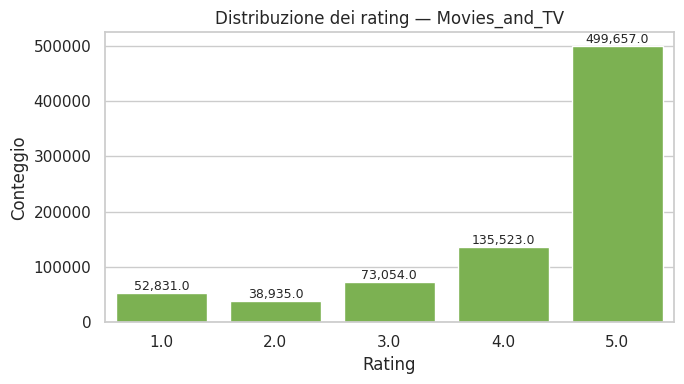

Rating medio: 4.238
% rating >= 4: 79.4 %  (tipico forte sbilanciamento positivo)


In [34]:
# Distribuzione dei rating
plt.figure(figsize=(7,4))
ax = sns.countplot(x="rating", data=df, color="#7AC142")
ax.set_title(f"Distribuzione dei rating — {CATEGORY}")
ax.set_xlabel("Rating"); ax.set_ylabel("Conteggio")
for p in ax.patches:
    ax.annotate(f"{p.get_height():,}", (p.get_x()+p.get_width()/2, p.get_height()),
                ha="center", va="bottom", fontsize=9)
plt.tight_layout(); plt.show()

print("Rating medio:", round(df["rating"].mean(), 3))
print("% rating >= 4:", round((df["rating"]>=4).mean()*100, 1), "%  (tipico forte sbilanciamento positivo)")

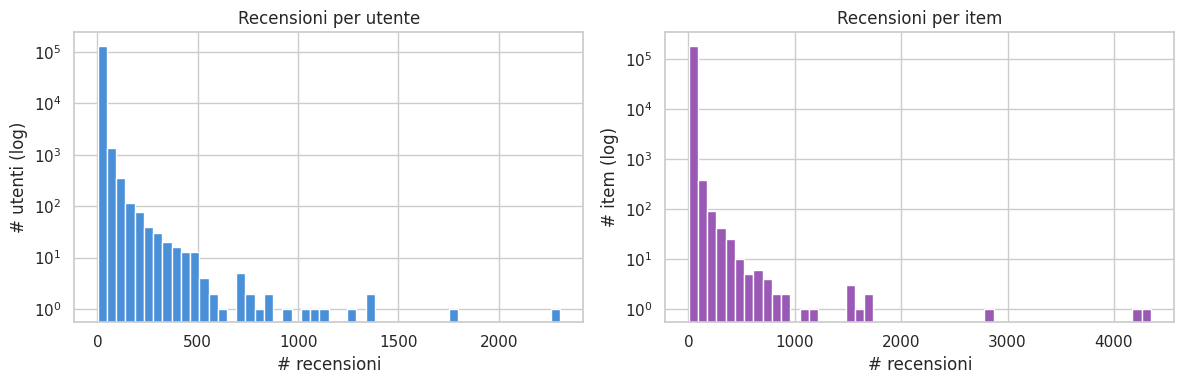

Sparsita della matrice utente-item: 99.9968%  (vicino al 100% = molto sparsa)


In [35]:
# Quante recensioni per utente e per item (long tail tipica)
rpu = df.groupby("user_id").size()
rpi = df.groupby("item_id").size()

fig, axes = plt.subplots(1, 2, figsize=(12,4))
axes[0].hist(rpu, bins=50, color="#4A90D9"); axes[0].set_yscale("log")
axes[0].set_title("Recensioni per utente"); axes[0].set_xlabel("# recensioni"); axes[0].set_ylabel("# utenti (log)")
axes[1].hist(rpi, bins=50, color="#9B59B6"); axes[1].set_yscale("log")
axes[1].set_title("Recensioni per item"); axes[1].set_xlabel("# recensioni"); axes[1].set_ylabel("# item (log)")
plt.tight_layout(); plt.show()

n_pairs = df["user_id"].nunique() * df["item_id"].nunique()
sparsity = 1 - len(df)/n_pairs
print(f"Sparsita della matrice utente-item: {sparsity*100:.4f}%  (vicino al 100% = molto sparsa)")

In [36]:
# Verified purchase e helpful vote
if "verified_purchase" in df.columns:
    print(df["verified_purchase"].value_counts(normalize=True).rename("quota"))
if "helpful_vote" in df.columns:
    print("\nHelpful vote — describe:")
    display(df["helpful_vote"].describe())

verified_purchase
True     0.803203
False    0.196797
Name: quota, dtype: float64

Helpful vote — describe:


,helpful_vote
count,800000.000000
mean,1.203811
std,10.812403
min,0.000000
25%,0.000000
50%,0.000000
75%,1.000000
max,2162.000000


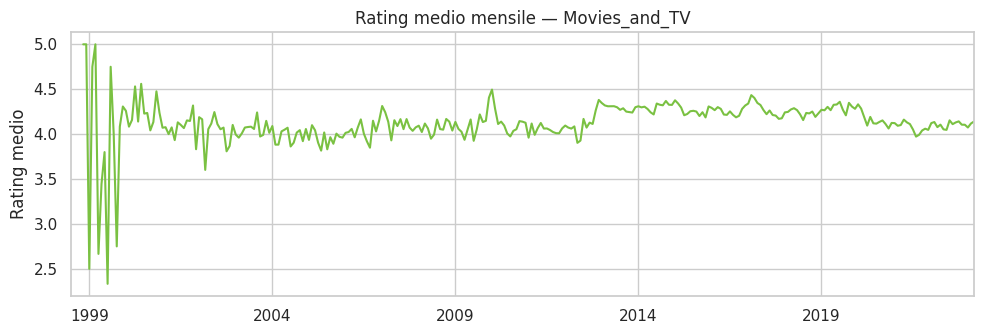

In [37]:
# Andamento del rating medio nel tempo
df["date"] = pd.to_datetime(df["timestamp"], unit="ms")
monthly = df.set_index("date")["rating"].resample("ME").mean()
plt.figure(figsize=(10,3.5))
monthly.plot(color="#7AC142")
plt.title(f"Rating medio mensile — {CATEGORY}"); plt.ylabel("Rating medio"); plt.xlabel("")
plt.tight_layout(); plt.show()

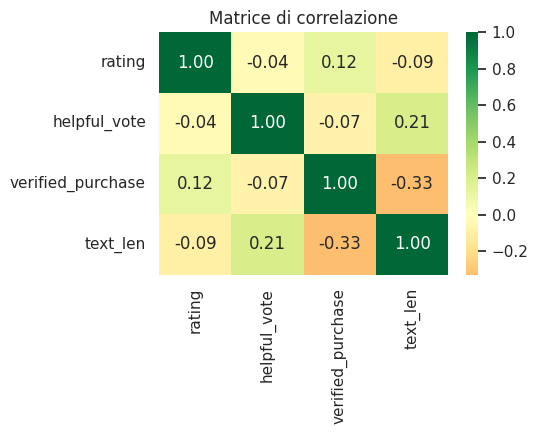

,rating,helpful_vote,verified_purchase,text_len
rating,1.000000,-0.037492,0.120298,-0.094738
helpful_vote,-0.037492,1.000000,-0.071213,0.206380
verified_purchase,0.120298,-0.071213,1.000000,-0.328751
text_len,-0.094738,0.206380,-0.328751,1.000000


In [38]:
# Analisi di correlazione tra variabili numeriche
df["text_len"] = df["text"].fillna("").str.len()
num_cols = [c for c in ["rating", "helpful_vote", "verified_purchase", "text_len"] if c in df.columns]
corr_df = df[num_cols].copy()
if "verified_purchase" in corr_df:
    corr_df["verified_purchase"] = corr_df["verified_purchase"].astype(int)
corr = corr_df.corr()
plt.figure(figsize=(5.5,4.5))
sns.heatmap(corr, annot=True, cmap="RdYlGn", center=0, fmt=".2f")
plt.title("Matrice di correlazione")
plt.tight_layout(); plt.show()
display(corr)

### Filtro di densita

Per rendere il CF significativo (e la matrice trattabile) teniamo solo utenti e item con un numero minimo di interazioni. Iteriamo il filtro finche stabile, perche rimuovere utenti puo far scendere item sotto soglia e viceversa.

In [39]:
# Sezione 1.3.2 — Analisi dei duplicati
n_prima = len(df)
dup_mask = df.duplicated(subset=["user_id", "item_id"], keep=False)
n_duplicati = dup_mask.sum()

# Deduplicazione: tieni l'ultima recensione per coppia (user, item)
df = df.sort_values("timestamp").drop_duplicates(["user_id", "item_id"], keep="last")
n_dopo = len(df)

tab_dup = pd.DataFrame({
    "Parametro": ["Recensioni iniziali", "Recensioni dopo deduplicazione", "Duplicati rimossi"],
    "Valore": [f"{n_prima:,}", f"{n_dopo:,}", f"{n_prima - n_dopo:,}"]
})
print(f"Duplicati trovati (coppie ripetute): {n_duplicati:,} ({n_duplicati/n_prima*100:.2f}% del totale)")
print("\nTabella 1.2 — Statistiche deduplicazione")
display(tab_dup)

Duplicati trovati (coppie ripetute): 4,002 (0.50% del totale)

Tabella 1.2 — Statistiche deduplicazione


,Parametro,Valore
0,Recensioni iniziali,"800,000"
1,Recensioni dopo deduplicazione,"797,999"
2,Duplicati rimossi,"2,001"


Sparsità matrice originale: 99.9969%  (prossima al 100%)


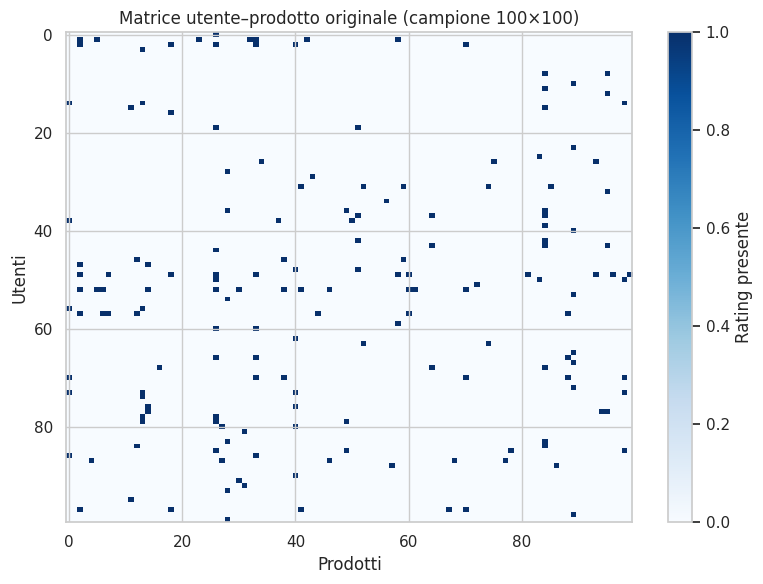

Nota: la quasi totalità delle celle è vuota → sparsità prossima al 100%.


In [40]:
# Sezione 1.3.3 — Sparsità della matrice originale
n_u_orig = df["user_id"].nunique()
n_i_orig = df["item_id"].nunique()
sparsita_orig = 1 - len(df) / (n_u_orig * n_i_orig)
print(f"Sparsità matrice originale: {sparsita_orig:.4%}  (prossima al 100%)")

# Visualizzazione: campione dei 100 utenti e 100 film più attivi
top_u_viz = df.groupby("user_id").size().sort_values(ascending=False).head(100).index
top_i_viz = df.groupby("item_id").size().sort_values(ascending=False).head(100).index
sample = df[df["user_id"].isin(top_u_viz) & df["item_id"].isin(top_i_viz)]
mat_viz = sample.pivot_table(index="user_id", columns="item_id", values="rating", aggfunc="mean")
mat_viz = mat_viz.reindex(index=top_u_viz, columns=top_i_viz)

plt.figure(figsize=(8, 6))
plt.imshow(mat_viz.notna(), aspect="auto", cmap="Blues", interpolation="nearest")
plt.title("Matrice utente–prodotto originale (campione 100×100)")
plt.xlabel("Prodotti"); plt.ylabel("Utenti")
plt.colorbar(label="Rating presente")
plt.tight_layout(); plt.show()
print("Nota: la quasi totalità delle celle è vuota → sparsità prossima al 100%.")

In [41]:
# Step A: k-core iterativo con soglie asimmetriche
def filter_min(df, min_u, min_i):
    prev = None
    cur = df.copy()
    iteration = 0
    while prev is None or len(cur) != prev:
        prev = len(cur)
        u_ok = cur.groupby("user_id").size()
        cur = cur[cur["user_id"].isin(u_ok[u_ok >= min_u].index)]
        i_ok = cur.groupby("item_id").size()
        cur = cur[cur["item_id"].isin(i_ok[i_ok >= min_i].index)]
        iteration += 1
    print(f"  k-core convergenza in {iteration} iterazioni")
    return cur

print(f"Step A — k-core iterativo (utenti≥{MIN_USER_RATINGS}, film≥{MIN_ITEM_RATINGS})...")
df_cf = filter_min(df, MIN_USER_RATINGS, MIN_ITEM_RATINGS)
print(f"  → {df_cf['user_id'].nunique()} utenti, {df_cf['item_id'].nunique()} film, {len(df_cf)} interazioni")

# Step B: top-K SOLO sugli utenti — i film non vengono toccati
# Motivo: vogliamo preservare l'intera distribuzione dei film (inclusa la coda lunga)
# e limitare solo la dimensione utenti per ragioni computazionali.
print(f"\nStep B — selezione top-{USERS_CAP} utenti più attivi (film invariati)...")
top_u = df_cf.groupby("user_id").size().sort_values(ascending=False).head(USERS_CAP).index
df_cf = df_cf[df_cf["user_id"].isin(top_u)]
print(f"  → {df_cf['user_id'].nunique()} utenti, {df_cf['item_id'].nunique()} film, {len(df_cf)} interazioni")

# Step C: secondo k-core per stabilizzare (alcuni film potrebbero essere scesi sotto soglia)
print("\nStep C — secondo k-core per stabilizzazione...")
df_cf = filter_min(df_cf, MIN_USER_RATINGS, MIN_ITEM_RATINGS)
print(f"  → {df_cf['user_id'].nunique()} utenti, {df_cf['item_id'].nunique()} film, {len(df_cf)} interazioni")

# Step D: deduplicazione — tieni l'ultima recensione per coppia (user, item)
# Motivo: l'utente potrebbe aver aggiornato il giudizio; l'ultima è la più rappresentativa.
df_cf = df_cf.sort_values("timestamp").drop_duplicates(["user_id", "item_id"], keep="last")

# Statistiche finali
n_u = df_cf["user_id"].nunique()
n_i = df_cf["item_id"].nunique()
n_r = len(df_cf)
density = n_r / (n_u * n_i)
print(f"\n{'='*50}")
print(f"Dataset finale: {n_u} utenti x {n_i} film = {n_r} interazioni")
print(f"Densità: {density:.4%}  |  Sparsità: {1-density:.4%}")
print(f"{'='*50}")

Step A — k-core iterativo (utenti≥5, film≥5)...
  k-core convergenza in 8 iterazioni
  → 25605 utenti, 25695 film, 362980 interazioni

Step B — selezione top-3000 utenti più attivi (film invariati)...
  → 3000 utenti, 25107 film, 154318 interazioni

Step C — secondo k-core per stabilizzazione...
  k-core convergenza in 2 iterazioni
  → 3000 utenti, 12000 film, 118425 interazioni

Dataset finale: 3000 utenti x 12000 film = 118425 interazioni
Densità: 0.3290%  |  Sparsità: 99.6710%


### Correlazione delle feature derivate (matrice CF filtrata)

Sulla matrice `df_cf` (post k-core) costruiamo feature di bias per utente e per item e ne analizziamo la correlazione con il rating. Serve a motivare i termini di baseline (μ + b_u + b_i) usati dal modello SVD.

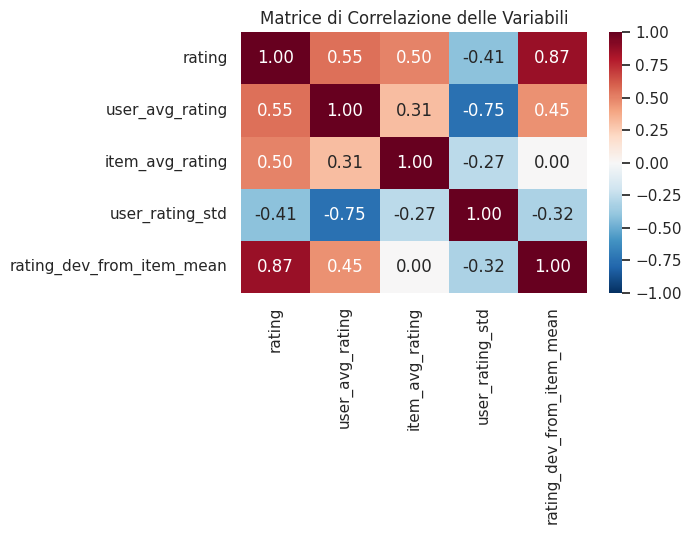

,rating,user_avg_rating,item_avg_rating,user_rating_std,rating_dev_from_item_mean
rating,1.000,0.547,0.500,-0.410,0.866
user_avg_rating,0.547,1.000,0.307,-0.749,0.455
item_avg_rating,0.500,0.307,1.000,-0.270,0.000
user_rating_std,-0.410,-0.749,-0.270,1.000,-0.317
rating_dev_from_item_mean,0.866,0.455,0.000,-0.317,1.000


In [42]:
# Feature derivate sulla matrice CF filtrata + correlazione
df_corr = df_cf.copy()
user_stats = df_cf.groupby("user_id")["rating"].agg(
    user_avg_rating="mean", user_rating_std="std"
).fillna(0)
item_stats = df_cf.groupby("item_id")["rating"].agg(
    item_avg_rating="mean"
)
df_corr = df_corr.join(user_stats, on="user_id").join(item_stats, on="item_id")
df_corr["rating_dev_from_item_mean"] = df_corr["rating"] - df_corr["item_avg_rating"]

corr_cols = ["rating", "user_avg_rating", "item_avg_rating", "user_rating_std", "rating_dev_from_item_mean"]
corr = df_corr[corr_cols].corr()

plt.figure(figsize=(7, 5.5))
sns.heatmap(corr, annot=True, cmap="RdBu_r", center=0, fmt=".2f", vmin=-1, vmax=1)
plt.title("Matrice di Correlazione delle Variabili")
plt.tight_layout()
plt.show()
display(corr.round(3))

Tabella 1.6 — Statistiche matrice utente–prodotto dopo il filtraggio


,Parametro,Valore
0,Utenti,"3,000"
1,Prodotti,"12,000"
2,Rating osservati,"118,425"
3,Dimensione matrice,"36,000,000"
4,Densità,0.3290%
5,Sparsità,99.6710%


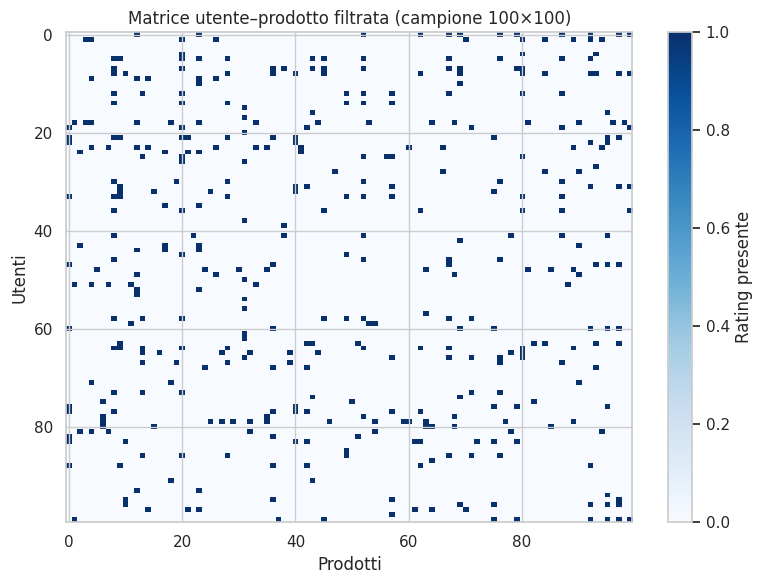

In [43]:
# Sezione 1.3.5 — Tabella riepilogativa matrice filtrata
n_u = df_cf["user_id"].nunique()
n_i = df_cf["item_id"].nunique()
n_r = len(df_cf)
dim = n_u * n_i
densita = n_r / dim

tab_filtrata = pd.DataFrame({
    "Parametro": ["Utenti", "Prodotti", "Rating osservati", "Dimensione matrice", "Densità", "Sparsità"],
    "Valore": [f"{n_u:,}", f"{n_i:,}", f"{n_r:,}", f"{dim:,}", f"{densita:.4%}", f"{1-densita:.4%}"]
})
print("Tabella 1.6 — Statistiche matrice utente–prodotto dopo il filtraggio")
display(tab_filtrata)

# Visualizzazione matrice filtrata (campione 100×100) per confronto con l'originale
top_u_f = df_cf.groupby("user_id").size().sort_values(ascending=False).head(100).index
top_i_f = df_cf.groupby("item_id").size().sort_values(ascending=False).head(100).index
samp_f = df_cf[df_cf["user_id"].isin(top_u_f) & df_cf["item_id"].isin(top_i_f)]
mat_f = samp_f.pivot_table(index="user_id", columns="item_id", values="rating", aggfunc="mean")
mat_f = mat_f.reindex(index=top_u_f, columns=top_i_f)

plt.figure(figsize=(8, 6))
plt.imshow(mat_f.notna(), aspect="auto", cmap="Blues", interpolation="nearest")
plt.title("Matrice utente–prodotto filtrata (campione 100×100)")
plt.xlabel("Prodotti"); plt.ylabel("Utenti")
plt.colorbar(label="Rating presente")
plt.tight_layout(); plt.show()

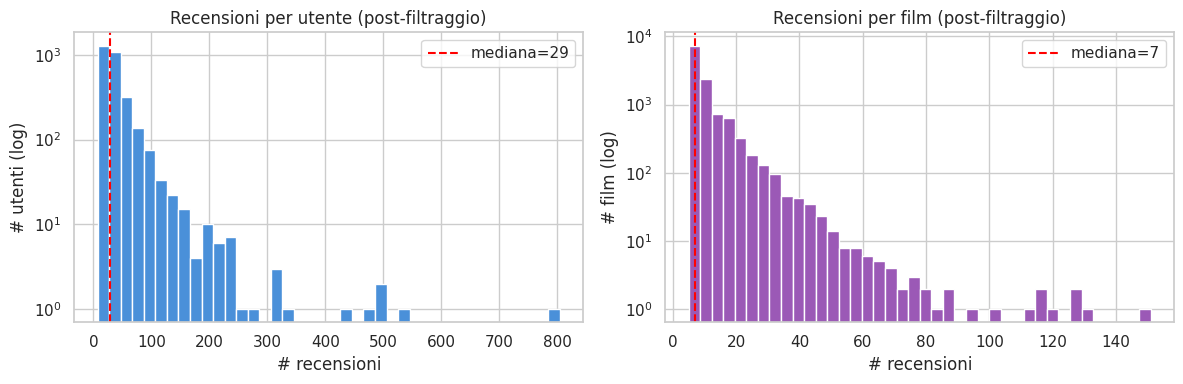

Distribuzione recensioni per UTENTE:


,Range,Count,%
0,5–9,1,0.0%
1,10–19,384,12.8%
2,20–49,2041,68.0%
3,50–99,445,14.8%
4,≥100,129,4.3%



Distribuzione recensioni per FILM:


,Range,Count,%
0,10–19,2872,23.9%
1,20–49,887,7.4%
2,50–99,51,0.4%
3,100–199,9,0.1%
4,≥200,0,0.0%


In [44]:
# Distribuzione interazioni per utente e per film dopo il filtraggio
rpu = df_cf.groupby("user_id").size()
rpi = df_cf.groupby("item_id").size()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(rpu, bins=40, color="#4A90D9")
axes[0].set_yscale("log")
axes[0].axvline(rpu.median(), color="red", linestyle="--", label=f"mediana={rpu.median():.0f}")
axes[0].set_title("Recensioni per utente (post-filtraggio)")
axes[0].set_xlabel("# recensioni"); axes[0].set_ylabel("# utenti (log)")
axes[0].legend()

axes[1].hist(rpi, bins=40, color="#9B59B6")
axes[1].set_yscale("log")
axes[1].axvline(rpi.median(), color="red", linestyle="--", label=f"mediana={rpi.median():.0f}")
axes[1].set_title("Recensioni per film (post-filtraggio)")
axes[1].set_xlabel("# recensioni"); axes[1].set_ylabel("# film (log)")
axes[1].legend()

plt.tight_layout()
plt.show()

# Tabelle distribuzione (utile per il report)
def dist_table(s, ranges):
    rows = []
    for lo, hi in ranges:
        mask = (s >= lo) & (s <= hi) if hi else (s >= lo)
        label = f"{lo}–{hi}" if hi else f"≥{lo}"
        rows.append({"Range": label, "Count": mask.sum(), "%": f"{mask.mean()*100:.1f}%"})
    return pd.DataFrame(rows)

print("Distribuzione recensioni per UTENTE:")
display(dist_table(rpu, [(5,9),(10,19),(20,49),(50,99),(100,None)]))

print("\nDistribuzione recensioni per FILM:")
display(dist_table(rpi, [(10,19),(20,49),(50,99),(100,199),(200,None)]))

## Sezione 1.4 — Analisi del dataset Metadata

In [45]:
# === SEZIONE 1.4 — ANALISI DATASET METADATA ===
# NB: il file dei metadati ha campi annidati eterogenei (es. details/Producers, a
# volte lista e a volte stringa) che mandano in errore il parser Arrow usato da
# load_dataset("json", ...). Lo leggiamo quindi riga per riga con json: robusto a
# qualunque schema. Teniamo un campione per le statistiche globali e, in piu', tutti
# i prodotti del core filtrato (df_cf), cosi' la Sezione 1.4.4 resta corretta.
import json as _json
from huggingface_hub import HfFileSystem

SAMPLE_META = 20000    # righe campionate per qualita'/lunghezze testo (abbassa per test)

meta_path = f"datasets/McAuley-Lab/Amazon-Reviews-2023/raw/meta_categories/meta_{CATEGORY}.jsonl"
item_core = set(df_cf["item_id"])

fs = HfFileSystem()
sample_rows, core_rows, seen_core = [], [], set()
n_meta_total = 0
with fs.open(meta_path, "rb") as f:
    for raw in f:
        try:
            ex = _json.loads(raw)
        except Exception:
            continue
        n_meta_total += 1
        if len(sample_rows) < SAMPLE_META:
            sample_rows.append(ex)
        pa = ex.get("parent_asin")
        if pa in item_core and pa not in seen_core:
            core_rows.append(ex)
            seen_core.add(pa)

# 'meta' = campione + tutti i prodotti del core (deduplicati su parent_asin)
meta = pd.DataFrame(sample_rows + core_rows).drop_duplicates("parent_asin").reset_index(drop=True)
print(f"Prodotti totali nel metadata della categoria: {n_meta_total:,}")
print(f"Righe in 'meta' (campione {SAMPLE_META:,} + {len(seen_core):,} prodotti del core): {meta.shape[0]:,}")
print("Campi disponibili:", list(meta.columns))

Prodotti totali nel metadata della categoria: 748,224
Righe in 'meta' (campione 100,000 + 12,000 prodotti del core): 110,217
Campi disponibili: ['main_category', 'title', 'subtitle', 'average_rating', 'rating_number', 'features', 'description', 'price', 'images', 'videos', 'store', 'categories', 'details', 'parent_asin', 'bought_together', 'author']


In [46]:
# Sezione 1.4.2 — Qualità dei dati: percentuale valori mancanti per campo
def pct_missing(col):
    s = meta[col]
    if s.apply(lambda x: isinstance(x, (list, np.ndarray))).any():
        # campo lista: vuoto = lista vuota
        return s.apply(lambda x: len(x) == 0 if isinstance(x, (list, np.ndarray)) else pd.isna(x)).mean()
    return s.isna().mean()

quality = pd.DataFrame({
    "Campo": meta.columns,
    "% Mancanti": [f"{pct_missing(c)*100:.2f}%" for c in meta.columns]
})
print("Tabella 1.x — Qualità dei dati (valori mancanti per campo)")
display(quality.sort_values("% Mancanti", ascending=False))

Tabella 1.x — Qualità dei dati (valori mancanti per campo)


,Campo,% Mancanti
15,author,99.99%
9,videos,94.86%
2,subtitle,90.45%
5,features,67.91%
10,store,48.05%
7,price,45.67%
6,description,24.11%
11,categories,16.33%
1,title,15.76%
14,bought_together,100.00%


Titoli:
  lunghezza media: 4.3 parole | mediana: 3

Descrizioni:
  lunghezza media: 71.7 parole | mediana: 37
  descrizioni vuote: 24.11%


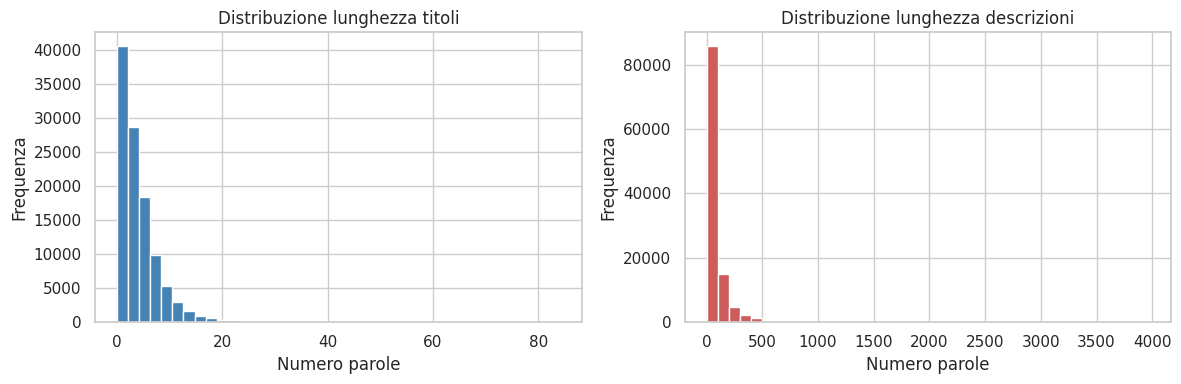

In [47]:
# Sezione 1.4.3 — Analisi componenti testuali
def join_list(x):
    if isinstance(x, (list, np.ndarray)):
        return " ".join(map(str, x))
    return "" if x is None else str(x)

meta["title_str"] = meta["title"].fillna("").astype(str)
meta["desc_str"] = meta["description"].apply(join_list)

meta["title_len"] = meta["title_str"].str.split().apply(len)
meta["desc_len"] = meta["desc_str"].str.split().apply(len)

pct_desc_vuote = (meta["desc_len"] == 0).mean()

print("Titoli:")
print(f"  lunghezza media: {meta['title_len'].mean():.1f} parole | mediana: {meta['title_len'].median():.0f}")
print("\nDescrizioni:")
print(f"  lunghezza media: {meta['desc_len'].mean():.1f} parole | mediana: {meta['desc_len'].median():.0f}")
print(f"  descrizioni vuote: {pct_desc_vuote:.2%}")

# Grafici distribuzione
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(meta["title_len"], bins=40, color="steelblue")
axes[0].set_title("Distribuzione lunghezza titoli")
axes[0].set_xlabel("Numero parole"); axes[0].set_ylabel("Frequenza")
axes[1].hist(meta["desc_len"], bins=40, color="indianred")
axes[1].set_title("Distribuzione lunghezza descrizioni")
axes[1].set_xlabel("Numero parole"); axes[1].set_ylabel("Frequenza")
plt.tight_layout(); plt.show()

Prodotti nel metadata originale: 748,224
Prodotti nel metadata_subset (intersezione con review): 12,000
Prodotti persi: 736,224

Statistiche testuali del subset:
  lunghezza media titoli: 2.6 parole
  descrizioni vuote: 43.71%
  lunghezza media descrizioni: 102.4 parole


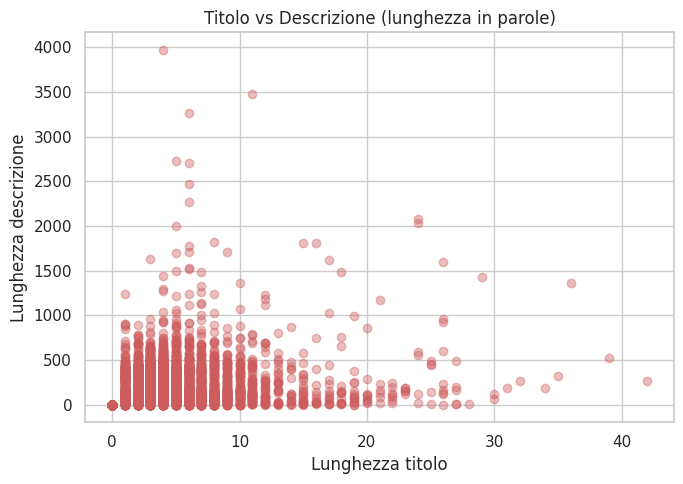

In [48]:
# Sezione 1.4.4 — Riduzione ai prodotti presenti nelle review filtrate
item_filtrati = set(df_cf["item_id"])
n_meta_orig = n_meta_total   # totale reale dei prodotti nel metadata
metadata_subset = meta[meta["parent_asin"].isin(item_filtrati)].copy()

print(f"Prodotti nel metadata originale: {n_meta_orig:,}")
print(f"Prodotti nel metadata_subset (intersezione con review): {len(metadata_subset):,}")
print(f"Prodotti persi: {n_meta_orig - len(metadata_subset):,}")

print("\nStatistiche testuali del subset:")
print(f"  lunghezza media titoli: {metadata_subset['title_len'].mean():.1f} parole")
print(f"  descrizioni vuote: {(metadata_subset['desc_len']==0).mean():.2%}")
print(f"  lunghezza media descrizioni: {metadata_subset['desc_len'].mean():.1f} parole")

# Scatter titolo vs descrizione (come Figura 1.3c del report)
plt.figure(figsize=(7, 5))
plt.scatter(metadata_subset["title_len"], metadata_subset["desc_len"], alpha=0.4, color="indianred")
plt.title("Titolo vs Descrizione (lunghezza in parole)")
plt.xlabel("Lunghezza titolo"); plt.ylabel("Lunghezza descrizione")
plt.tight_layout(); plt.show()

## 2.1 — Preparazione della Matrice Utente–Prodotto

Costruiamo la matrice sparsa utente×item in cui ogni cella contiene il rating (o resta vuota se l'interazione non esiste). Prima dividiamo i dati in **train (80%)** e **test (20%)**: il mapping da ID originali a indici interi viene definito **solo sul train**, così da simulare correttamente uno scenario reale ed evitare il **cold-start** (utenti o item presenti nel test ma mai visti nel train vengono scartati). Usiamo il formato sparso **CSR** per efficienza di memoria.

In [49]:
import numpy as np
import pandas as pd
from scipy.sparse import coo_matrix, csr_matrix
from sklearn.model_selection import train_test_split

RANDOM_STATE = 42

# 2.1.2 Train-test split (80/20)
train_df, test_df = train_test_split(
    df_cf[["user_id", "item_id", "rating"]],
    test_size=0.20, random_state=RANDOM_STATE
)

# 2.1.3 Indicizzazione: mapping ID -> interi consecutivi, definito SUL TRAIN
user_ids = train_df["user_id"].unique()
item_ids = train_df["item_id"].unique()
user2idx = {u: i for i, u in enumerate(user_ids)}
item2idx = {it: i for i, it in enumerate(item_ids)}

# Rimuovi dal test gli utenti/item non visti nel train (cold-start)
n_test_before = len(test_df)
test_df = test_df[test_df["user_id"].isin(user2idx) & test_df["item_id"].isin(item2idx)]
print(f"Indicizzazione: utenti = 0..{len(user_ids)-1}, item = 0..{len(item_ids)-1}")
print(f"Righe test rimosse per cold-start: {n_test_before - len(test_df)}")

# 2.1.4 Costruzione matrice utente-prodotto (COO -> CSR)
rows = train_df["user_id"].map(user2idx).values
cols = train_df["item_id"].map(item2idx).values
vals = train_df["rating"].values
M = coo_matrix((vals, (rows, cols)), shape=(len(user_ids), len(item_ids))).tocsr()
print(f"Matrice utente-prodotto: {M.shape}, non-zero: {M.nnz}")

Indicizzazione: utenti = 0..2999, item = 0..11998
Righe test rimosse per cold-start: 6
Matrice utente-prodotto: (3000, 11999), non-zero: 94740


## 2.2 — Ricerca della Configurazione Ottimale del Modello K-NN

Usiamo **KNNBaseline** di Surprise, che calcola le componenti di baseline (media globale µ, bias utente bᵤ, bias item bᵢ) tramite **ALS**, e poi affina la predizione con i K vicini più simili pesati dalla similarità. Eseguiamo una grid search sulle combinazioni: similarità (cosine, pearson), shrinkage (10, 50, 100), modalità (user-based / item-based), e valori di K (5,10,20,30,40,60,80,100). Per ogni configurazione calcoliamo **RMSE** e **MSE** sul test set, e selezioniamo quella con errore minimo.

In [ ]:
from surprise import Dataset, Reader, KNNBaseline, accuracy
import itertools

reader = Reader(rating_scale=(1, 5))

# Ricostruiamo train/test in formato Surprise mantenendo lo split gia fatto
trainset = Dataset.load_from_df(train_df[["user_id","item_id","rating"]], reader).build_full_trainset()
testset = list(test_df[["user_id","item_id","rating"]].itertuples(index=False, name=None))

# Griglia parametri: similarita x modalita x K.
# NB: in Surprise lo "shrinkage" agisce SOLO sulla similarita pearson_baseline, non su
# cosine/pearson; variarlo qui produrrebbe solo righe duplicate, quindi lo fissiamo.
sim_names = ["cosine", "pearson"]
user_based_opts = [True, False]
k_values = [5, 10, 20, 30, 40, 60, 80, 100]
SHRINK = 100

results = []
for sim_name, ub in itertools.product(sim_names, user_based_opts):
    for k in k_values:
        algo = KNNBaseline(
            k=k,
            sim_options={"name": sim_name, "user_based": ub, "shrinkage": SHRINK},
            bsl_options={"method": "als"},
            verbose=False
        )
        algo.fit(trainset)
        preds = algo.test(testset)
        rmse = accuracy.rmse(preds, verbose=False)
        mse = rmse ** 2
        results.append({
            "similarita": sim_name, "shrinkage": SHRINK,
            "modalita": "user-based" if ub else "item-based",
            "k": k, "RMSE": rmse, "MSE": mse
        })

res_df = pd.DataFrame(results).sort_values("RMSE").reset_index(drop=True)
print("Top 10 configurazioni per RMSE:")
display(res_df.head(10))

### 2.2.3 — Risultati sperimentali

Visualizziamo l'andamento dell'RMSE al variare di K, separato per ciascuna combinazione di similarità e modalità, per capire dove si trova il minimo e come si comporta il modello.

In [ ]:
import matplotlib.pyplot as plt

best = res_df.iloc[0]
print("=== CONFIGURAZIONE OTTIMALE ===")
print(f"Similarita: {best['similarita']} | Shrinkage: {best['shrinkage']} | "
      f"Modalita: {best['modalita']} | k: {best['k']}")
print(f"RMSE = {best['RMSE']:.5f} | MSE = {best['MSE']:.5f}")

# Grafico RMSE vs k per la configurazione vincente (fissando similarita+shrinkage+modalita)
mask = ((res_df["similarita"]==best["similarita"]) &
        (res_df["shrinkage"]==best["shrinkage"]) &
        (res_df["modalita"]==best["modalita"]))
sub = res_df[mask].sort_values("k")

plt.figure(figsize=(8,5))
plt.plot(sub["k"], sub["RMSE"], marker="o", label="RMSE")
plt.plot(sub["k"], sub["MSE"], marker="s", label="MSE")
plt.axvline(best["k"], color="red", linestyle="--", label=f"Best k={best['k']}")
plt.xlabel("k (numero vicini)"); plt.ylabel("Valore errore")
plt.title(f"RMSE e MSE al variare di k ({best['similarita']}, {best['modalita']}, shrink={best['shrinkage']})")
plt.legend(); plt.grid(True, alpha=0.3); plt.tight_layout(); plt.show()

## 2.3 — Filling della Matrice di Rating

Usando la configurazione ottimale, riaddestriamo il modello su tutto il dataset e prediciamo **tutti** i rating mancanti (le coppie utente-item non osservate). Otteniamo così una matrice densa, dove ogni cella ha un valore (osservato o predetto), pronta per il clustering e le raccomandazioni.

In [ ]:
# 2.3 — Filling della matrice di rating con la configurazione ottimale K-NN
# Manteniamo il processo originale (matrice densa su TUTTI gli item), ma riempita in modo
# ITERATIVO per non saturare la RAM. Il problema del codice precedente era build_anti_testset(),
# che costruiva in un colpo solo tutte le coppie mancanti (milioni di tuple) + altrettanti
# oggetti Prediction -> OOM e riavvio del kernel. Qui: osservati via pivot, mancanti predetti
# utente-per-utente scrivendo i float direttamente nell'array (RAM costante, nessuna lista gigante).
import numpy as np

# None = TUTTI gli item (fedele al processo iniziale). Metti un numero (es. 2000) SOLO se
# vuoi velocizzare i test riducendo la matrice ai top item piu' recensiti.
N_ITEMS_DENSE = None

# Riaddestra il modello ottimale su tutto df_cf
full_trainset = Dataset.load_from_df(df_cf[["user_id", "item_id", "rating"]], reader).build_full_trainset()
best_algo = KNNBaseline(
    k=int(best["k"]),
    sim_options={"name": best["similarita"],
                 "user_based": best["modalita"] == "user-based",
                 "shrinkage": int(best["shrinkage"])},
    bsl_options={"method": "als"},
    verbose=False
)
best_algo.fit(full_trainset)

all_users = df_cf["user_id"].unique()
if N_ITEMS_DENSE is None:
    all_items = df_cf["item_id"].unique().tolist()
else:
    all_items = df_cf["item_id"].value_counts().head(N_ITEMS_DENSE).index.tolist()

# 1) Osservati -> pivot (vettoriale e veloce)
sub = df_cf[df_cf["item_id"].isin(set(all_items))]
rating_matrix = (sub.pivot_table(index="user_id", columns="item_id",
                                 values="rating", aggfunc="mean")
                    .reindex(index=all_users, columns=all_items))

# 2) Mancanti -> predizioni K-NN, ITERANDO utente per utente (RAM costante)
arr = rating_matrix.to_numpy()
users = list(rating_matrix.index)
items = list(rating_matrix.columns)
n_missing = int(np.isnan(arr).sum())
print(f"Matrice densa: {arr.shape[0]} utenti x {arr.shape[1]} item | celle da predire: {n_missing:,}")
print("(processo iterativo: con tutti gli item puo' richiedere diversi minuti)")
for ui, u in enumerate(users):
    nan_cols = np.where(np.isnan(arr[ui]))[0]
    for jc in nan_cols:
        arr[ui, jc] = best_algo.predict(u, items[jc]).est
    if (ui + 1) % 500 == 0:
        print(f"  utenti completati: {ui + 1}/{len(users)}")

rating_matrix = pd.DataFrame(arr, index=users, columns=items)
print(f"Filling completato. NaN residui: {int(rating_matrix.isna().to_numpy().sum())}")
rating_matrix.iloc[:5, :5]

## 2.4 — Segmentazione degli Utenti (Clustering)

Ogni utente è ora un vettore di rating (una riga della matrice densa). Riduciamo la dimensionalità con **PCA** (20 componenti per il clustering, 2 per la visualizzazione). Poi applichiamo **K-Means**: per usare la cosine similarity normalizziamo i vettori a norma L2 (su vettori normalizzati la distanza euclidea è equivalente alla cosine). Scegliamo il numero di cluster k con **Elbow Method** (inertia) e **Silhouette Score**.

In [ ]:
from sklearn.preprocessing import normalize
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# 2.4.1 Preprocessing + PCA
X = rating_matrix.fillna(rating_matrix.mean()).values
X_norm = normalize(X, norm="l2")   # per cosine via euclidea

pca20 = PCA(n_components=20, random_state=RANDOM_STATE)
X_pca = pca20.fit_transform(X_norm)

# 2.4.2 Scelta di k: Elbow + Silhouette
K_range = range(2, 15)
inertias, silhouettes = [], []
for k in K_range:
    km = KMeans(n_clusters=k, init="k-means++", n_init=10, random_state=RANDOM_STATE)
    labels = km.fit_predict(X_pca)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_pca, labels))

fig, ax = plt.subplots(1, 2, figsize=(12,4))
ax[0].plot(list(K_range), inertias, marker="o", color="#4A90D9")
ax[0].set_title("Elbow Method - KMeans"); ax[0].set_xlabel("Numero di cluster (k)"); ax[0].set_ylabel("Inertia")
ax[1].plot(list(K_range), silhouettes, marker="o", color="#7AC142")
ax[1].set_title("Silhouette Score"); ax[1].set_xlabel("Numero di cluster (k)"); ax[1].set_ylabel("Silhouette")
plt.tight_layout(); plt.show()

### 2.4.3 — Clustering finale

Scelto il k ottimale (in base ai due criteri sopra), eseguiamo il K-Means definitivo e profiliamo ogni cluster: numero di utenti, rating medio, recensioni medie per utente. Questo permette di interpretare i segmenti (utenti positivi, equilibrati, critici).

In [ ]:
# Scelta di k dai grafici sopra (Elbow + Silhouette): k=2 ha il Silhouette piu' alto
# (~0.49) ma da' solo 2 macro-gruppi; k=6 cadeva in un minimo locale (~0.07).
# k=4 e' il miglior compromesso: separazione ancora buona (~0.35) e segmenti azionabili.
best_k_clusters = 4

km = KMeans(n_clusters=best_k_clusters, init="k-means++", n_init=10, random_state=RANDOM_STATE)
user_clusters = pd.Series(km.fit_predict(X_pca), index=rating_matrix.index, name="cluster")

# Profilazione dei cluster
recensioni_per_user = df_cf.groupby("user_id").size()
prof = pd.DataFrame({
    "cluster": user_clusters,
    "rating_medio": rating_matrix.mean(axis=1),
    "recensioni": recensioni_per_user.reindex(rating_matrix.index)
})
summary = prof.groupby("cluster").agg(
    n_utenti=("rating_medio", "size"),
    rating_medio=("rating_medio", "mean"),
    recensioni_per_user=("recensioni", "mean")
).round(2)
print("Statistiche dei cluster individuati:")
display(summary)

### 2.4.4 — Visualizzazione cluster

Proiettiamo gli utenti nello spazio delle prime 2 componenti principali, colorando per cluster, per vedere la separazione dei segmenti.

In [ ]:
pca2 = PCA(n_components=2, random_state=RANDOM_STATE)
X_2d = pca2.fit_transform(X_norm)

plt.figure(figsize=(9,6))
for c in range(best_k_clusters):
    mask = user_clusters.values == c
    plt.scatter(X_2d[mask,0], X_2d[mask,1], s=12, alpha=0.6, label=f"Cluster {c}")
plt.xlabel("PC1"); plt.ylabel("PC2"); plt.title("Cluster Utenti (PCA 2D)")
plt.legend(); plt.tight_layout(); plt.show()

## 2.5 — Generazione delle Raccomandazioni Top-N

Per ogni utente ordiniamo gli item **non ancora valutati** in base al rating predetto, e prendiamo i primi N. Mostriamo poi le raccomandazioni per un utente rappresentativo di ciascun cluster, per osservare come i segmenti ricevano suggerimenti coerenti col loro profilo.

In [ ]:
TOP_N = 10
rated_by_user = df_cf.groupby("user_id")["item_id"].agg(set).to_dict()

# NB: la matrice densa e' clippata a [1,5], quindi molti item finiscono esattamente a
# 5.00 e un Top-N ordinato su quei valori sarebbe una classifica di pari-merito arbitraria.
# Ordiniamo quindi sulle stime NON troncate (clip=False), che differenziano gli item.
# (i punteggi possono superare 5: sono score di ranking, non rating finali)
def top_n_for_user(user, n=TOP_N):
    seen = rated_by_user.get(user, set())
    candidates = [it for it in all_items if it not in seen]
    scores = pd.Series(
        {it: best_algo.predict(user, it, clip=False).est for it in candidates}
    ).sort_values(ascending=False)
    return scores.head(n)

# Un utente rappresentativo per cluster (il primo di ciascun gruppo)
print("Top-N raccomandazioni per un utente rappresentativo di ogni cluster:\n")
for c in range(best_k_clusters):
    rep_user = user_clusters[user_clusters==c].index[0]
    recs = top_n_for_user(rep_user)
    print(f"--- Cluster {c} | utente {rep_user} | rating medio predetto: {recs.mean():.2f} ---")
    for item, est in recs.items():
        print(f"    {item}  ->  {est:.2f}")
    print()

## 2.6 — Matrix Factorization (SVD) e Confronto Finale

Applichiamo un secondo approccio: la decomposizione **SVD**, che approssima la matrice con k fattori latenti, catturando strutture nascoste nelle preferenze. Confrontiamo SVD col miglior KNNBaseline in termini di RMSE/MSE, usando lo stesso train/test split per un confronto equo.

In [ ]:
from surprise import SVD

# SVD addestrato sullo stesso trainset, valutato sullo stesso testset
svd = SVD(n_factors=50, random_state=RANDOM_STATE)
svd.fit(trainset)
svd_preds = svd.test(testset)
svd_rmse = accuracy.rmse(svd_preds, verbose=False)
svd_mse = svd_rmse ** 2

confronto = pd.DataFrame({
    "Modello": ["KNNBaseline (ottimizzato)", "SVD (50 fattori latenti)"],
    "RMSE": [best["RMSE"], svd_rmse],
    "MSE": [best["MSE"], svd_mse]
}).round(4)
print("Confronto KNNBaseline vs SVD:")
display(confronto)

ax = confronto.set_index("Modello")[["RMSE","MSE"]].plot(
    kind="bar", figsize=(7,4), color=["#7AC142","#4A90D9"], rot=0)
ax.set_ylabel("Errore"); ax.set_title("KNNBaseline vs SVD")
plt.tight_layout(); plt.show()

riduzione = (best["RMSE"] - svd_rmse) / best["RMSE"] * 100
print(f"SVD riduce l'RMSE del {riduzione:.1f}% rispetto a KNNBaseline (RMSE piu' basso = meglio).")

### 2.6.3 — Analisi delle raccomandazioni

Confrontiamo qualitativamente le Top-10 dei due modelli per un utente campione: misuriamo l'**overlap** (quanti item in comune) e la **dispersione** dei punteggi predetti, per capire se SVD produce raccomandazioni più diversificate rispetto al KNN.

In [ ]:
# Costruisci la matrice densa anche per SVD per confronto Top-N
sample_user = rating_matrix.index[0]

# Top-N da KNN (gia in rating_matrix)
knn_top = set(top_n_for_user(sample_user).index)

# Top-N da SVD: predici gli item non visti per sample_user
seen = rated_by_user.get(sample_user, set())
svd_scores = {it: svd.predict(sample_user, it, clip=False).est for it in all_items if it not in seen}
svd_top_series = pd.Series(svd_scores).sort_values(ascending=False).head(TOP_N)
svd_top = set(svd_top_series.index)

overlap = len(knn_top & svd_top)
print(f"Utente campione: {sample_user}")
print(f"Overlap Top-{TOP_N} tra KNN e SVD: {overlap}/{TOP_N} item in comune")
print(f"Dispersione punteggi KNN (std): {top_n_for_user(sample_user).std():.3f}")
print(f"Dispersione punteggi SVD (std): {svd_top_series.std():.3f}")

## 2.7 — Conclusioni

Riepilogo dei risultati: la configurazione KNN ottimale trovata, il confronto con SVD, i punti di forza (semplicità, interpretabilità) e i limiti del CF (sensibilità alla sparsità, cold-start, assenza di informazione sul contenuto — che motiva il passaggio al **Content-Based** del capitolo successivo).

In [ ]:
print("="*55)
print("RIEPILOGO COLLABORATIVE FILTERING")
print("="*55)
print(f"KNN ottimale: {best['similarita']}, {best['modalita']}, "
      f"shrink={best['shrinkage']}, k={best['k']}")
print(f"  RMSE = {best['RMSE']:.4f} | MSE = {best['MSE']:.4f}")
print(f"SVD (50 fattori): RMSE = {svd_rmse:.4f} | MSE = {svd_mse:.4f}")
print(f"Numero cluster utenti: {best_k_clusters}")
print(f"Modello migliore: {'SVD' if svd_rmse < best['RMSE'] else 'KNNBaseline'}")
print("="*55)

## Conclusioni Progetto Base

Sintesi da riportare nel report (riempire con i tuoi numeri):

- **Dataset / EDA:** sparsita, sbilanciamento verso rating alti, long-tail di utenti/item, correlazioni deboli tra rating e helpful_vote / lunghezza testo.
- **K-NN ottimale:** indica metrica di similarita, K e user/item based vincenti + RMSE/MSE.
- **Clustering:** numero di segmenti scelto (Elbow/Silhouette) e descrizione qualitativa dei cluster.
- **Top-N:** esempio di lista raccomandata.
- **K-NN vs Matrix Factorization:** quale generalizza meglio e perche (la MF tende a gestire meglio la sparsita catturando fattori latenti).

> Prossimi notebook: **Intermedio** (content-based con TF-IDF e transformers) e **Avanzato** (sentiment analysis).

---
# PARTE 2 — Livello Intermedio: Sistema di Raccomandazione Content-Based

## 3.0 — Obiettivi e impostazione

Il Collaborative Filtering (Parte 1) ignora il *contenuto* dei film e sfrutta solo le co-occorrenze di rating. Qui costruiamo un sistema **content-based**: ogni film e' rappresentato dai suoi attributi testuali (`title` + `description`) e i rating sono predetti per analogia di contenuto.

Passi (consegna livello intermedio):
1. **Preprocessing NLP** dei campi testuali (3.1)
2. **Embedding** con tecnica frequenziale **TF-IDF** (3.2) e tecnica neurale **transformer** `all-MiniLM-L6-v2` (3.3)
3. **Predizione dei rating con K-NN** per ogni utente usando entrambi gli embedding (3.4)
4. **Valutazione critica** TF-IDF vs transformer (3.6)
5. **Valutazione critica** Content-Based vs Collaborative Filtering (3.7)

In **3.5** alcune visualizzazioni extra (matrici di similarità, mappa semantica, raccomandazione "spiegata"): non richieste dalla consegna, ma utili al report.

Usiamo lo **stesso split train/test** del CF (`train_df` / `test_df`): RMSE e MSE sono cosi' direttamente confrontabili.

In [ ]:
# === PARTE 2 — Caricamento dei metadati testuali (self-contained) ===
# Sezione indipendente dalla 1.4: se 'meta' esiste gia lo riusa, altrimenti carica.
from datasets import load_dataset

try:
    meta
except NameError:
    import json, fsspec
    def load_meta(category, streaming=True, max_rows=None):
        # Lettura riga-per-riga: evita l'inferenza di schema di pyarrow che fallisce
        # quando un campo annidato (es. details.Producers) cambia tipo (array -> string).
        url = f"hf://datasets/McAuley-Lab/Amazon-Reviews-2023/raw/meta_categories/meta_{category}.jsonl"
        rows = []
        with fsspec.open(url, "r", encoding="utf-8") as f:
            for line in f:
                line = line.strip()
                if not line:
                    continue
                rows.append(json.loads(line))
                if max_rows and len(rows) >= max_rows:
                    break
        return pd.DataFrame(rows)
    meta = load_meta(CATEGORY)
    print("Metadata caricati:", meta.shape)

def _join_list(x):
    if isinstance(x, (list, np.ndarray)):
        return " ".join(map(str, x))
    return "" if x is None else str(x)

# Campo testuale = title + description (i campi richiesti dalla consegna)
meta["title_str"] = meta["title"].fillna("").astype(str)
meta["desc_str"]  = meta["description"].apply(_join_list)
meta["text_raw"]  = (meta["title_str"].str.strip() + ". " + meta["desc_str"].str.strip()).str.strip()

# Tieni solo i prodotti presenti nelle review filtrate (df_cf) e con testo non vuoto
items_cf = set(df_cf["item_id"])
cb = (meta[meta["parent_asin"].isin(items_cf)]
        .drop_duplicates("parent_asin")
        .copy())
cb = cb[cb["text_raw"].str.split().apply(len) > 0].reset_index(drop=True)

# Mapping item_id -> riga nelle matrici di embedding
pos = {asin: i for i, asin in enumerate(cb["parent_asin"])}
print(f"Item con testo usabile: {len(cb):,} su {len(items_cf):,} item del CF "
      f"({len(cb)/len(items_cf):.1%} di copertura)")

## 3.1 — Preprocessing dei campi testuali

Pipeline NLP vista in laboratorio: minuscolo, tokenizzazione, rimozione di punteggiatura/numeri e stopword, **stemming** (Porter). Il testo pulito alimenta il TF-IDF; il transformer riceve invece il **testo grezzo**, perche' e' pre-addestrato su linguaggio naturale e perderebbe informazione su token stemmati.

In [ ]:
# === 3.1 — Preprocessing NLP (tecniche viste in laboratorio) ===
import re
import nltk
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer

nltk.download("stopwords", quiet=True)

STOP = set(stopwords.words("english"))
stemmer = PorterStemmer()
_token_re = re.compile(r"[a-z]+")

def preprocess(text):
    tokens = _token_re.findall(text.lower())               # solo lettere, minuscolo
    tokens = [t for t in tokens if t not in STOP and len(t) > 2]
    tokens = [stemmer.stem(t) for t in tokens]
    return " ".join(tokens)

cb["text_clean"] = cb["text_raw"].apply(preprocess)

# Esempio prima/dopo
ex = cb.iloc[0]
print("RAW   :", ex["text_raw"][:200])
print("CLEAN :", ex["text_clean"][:200])

## 3.2 — Embedding frequenziale (TF-IDF)

Rappresentazione sparsa basata sulla frequenza dei termini pesata per la rarita' nel corpus (`idf`). Usiamo unigrammi + bigrammi, `min_df=2` per scartare termini rari/rumore e un cap a 5000 feature. Le righe sono L2-normalizzate, quindi il prodotto scalare equivale alla **similarita' coseno**.

In [ ]:
# === 3.2 — Embedding frequenziale: TF-IDF ===
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import normalize

tfidf = TfidfVectorizer(max_features=5000, min_df=2, ngram_range=(1, 2))
X_tfidf = tfidf.fit_transform(cb["text_clean"])     # (n_item, V) sparsa
X_tfidf = normalize(X_tfidf, norm="l2")             # cosine = prodotto scalare
print("Matrice TF-IDF:", X_tfidf.shape, "| dim. vocabolario:", len(tfidf.vocabulary_))

## 3.3 — Embedding neurale (transformer)

`all-MiniLM-L6-v2` (Sentence-Transformers) mappa ogni testo in un vettore **denso di 384 dimensioni** che cattura la semantica (sinonimi, contesto), non la semplice sovrapposizione di parole. Gli embedding sono gia' L2-normalizzati in uscita.

In [ ]:
# === 3.3 — Embedding neurale: transformer (all-MiniLM-L6-v2) ===
from sentence_transformers import SentenceTransformer

st_model = SentenceTransformer("all-MiniLM-L6-v2")   # 384 dim, usa GPU se disponibile
X_bert = st_model.encode(
    cb["text_raw"].tolist(),
    batch_size=64,
    show_progress_bar=True,
    normalize_embeddings=True,        # output gia L2-normalizzato -> cosine
)
X_bert = np.asarray(X_bert, dtype=np.float32)
print("Matrice transformer:", X_bert.shape)

## 3.4 — Predizione dei rating con K-NN

Per ogni coppia (utente *u*, film *i*) del test:
- recuperiamo i film che *u* ha valutato nel **train**;
- calcoliamo la similarita' coseno tra l'embedding di *i* e quelli dei film visti;
- prediciamo il rating come media dei rating dei **K=20 film piu' simili**, pesata dalla similarita':

$$\hat{r}(u,i) = \frac{\sum_{j \in N_k(i)\,\cap\,visti(u)} sim(i,j)\cdot r_{uj}}{\sum_j sim(i,j)}$$

Se l'utente non ha vicini utili, fallback alla sua media (o alla media globale). Le predizioni sono clippate nell'intervallo dei rating.

In [ ]:
# === 3.4 — Predizione dei rating con K-NN content-based ===
from scipy.sparse import issparse

LO, HI = RATING_SCALE

def _build_profiles(train_df, pos):
    """user_id -> (indici item, rating) sui soli item con testo."""
    prof = {}
    sub = train_df[train_df["item_id"].isin(pos)]
    for u, it, r in sub[["user_id", "item_id", "rating"]].itertuples(index=False):
        prof.setdefault(u, ([], []))
        prof[u][0].append(pos[it]); prof[u][1].append(r)
    return {u: (np.array(a), np.array(b, dtype=float)) for u, (a, b) in prof.items()}

def content_knn_predict(E, train_df, test_df, pos, k=20):
    mu = train_df["rating"].mean()
    prof = _build_profiles(train_df, pos)
    test_cb = test_df[test_df["item_id"].isin(pos)]
    preds, trues = [], []
    for u, grp in test_cb.groupby("user_id"):
        true_r = grp["rating"].values
        if u not in prof:                        # utente senza storico testuale
            preds.extend([mu] * len(grp)); trues.extend(true_r); continue
        idx, rat = prof[u]
        tgt = grp["item_id"].map(pos).values
        Er, Et = E[idx], E[tgt]
        sims = Et @ Er.T
        sims = sims.toarray() if issparse(sims) else np.asarray(sims)
        for row, tr in zip(sims, true_r):
            order = np.argsort(-row)[:k]
            w = row[order]; m = w > 0
            if m.sum() == 0:
                preds.append(rat.mean())         # fallback: media utente
            else:
                preds.append(float(np.dot(w[m], rat[order][m]) / w[m].sum()))
            trues.append(tr)
    preds = np.clip(preds, LO, HI)
    return np.array(preds), np.array(trues)

def rmse_mse(pred, true):
    mse = float(np.mean((pred - true) ** 2))
    return mse ** 0.5, mse

K_CB = 20
p_tf, y   = content_knn_predict(X_tfidf, train_df, test_df, pos, k=K_CB)
p_be, _   = content_knn_predict(X_bert,  train_df, test_df, pos, k=K_CB)

rmse_tf, mse_tf = rmse_mse(p_tf, y)
rmse_be, mse_be = rmse_mse(p_be, y)
print(f"Coppie di test valutate: {len(y):,} (su {len(test_df):,} del test set CF)")
print(f"TF-IDF      : RMSE = {rmse_tf:.4f} | MSE = {mse_tf:.4f}")
print(f"Transformer : RMSE = {rmse_be:.4f} | MSE = {mse_be:.4f}")

## 3.5 — Visualizzazioni della similarità e raccomandazione spiegata

In questa sezione *guardiamo* cosa hanno imparato i due tipi di embedding (TF-IDF e Transformer)
e costruiamo una raccomandazione **leggibile**, in cui si capisce *perché* un film viene consigliato.

### Cella A — Matrici di similarità complete (calcolate una volta sola)

Per confrontare i film fra loro serve, per ogni coppia di film, un numero che dice *quanto si somigliano*.
Poiché i vettori sono già normalizzati (lunghezza 1), il **prodotto scalare** tra due film **è** la loro
*cosine similarity* (1 = identici, 0 = nessuna relazione). Qui calcoliamo le due matrici item×item una volta
sola e le riusiamo in tutte le celle successive (così non rifacciamo lo stesso conto ogni volta).
Creiamo anche delle copie con la **diagonale a −∞**: servono per il *ranking*, così quando cerchiamo i film
più simili a X il film X non risulta vicino di se stesso.

In [ ]:
# === Cella A — Matrici di similarità item-item complete (calcolate una volta) ===
import numpy as np
from scipy.sparse import issparse

# Prodotto scalare tra vettori L2-normalizzati = cosine similarity.
# La matrice TF-IDF è sparsa: il prodotto resta sparso -> lo rendo denso per le viz.
S_tfidf = X_tfidf @ X_tfidf.T
S_tfidf = S_tfidf.toarray() if issparse(S_tfidf) else np.asarray(S_tfidf)
S_tfidf = S_tfidf.astype(np.float32)

S_bert = (X_bert @ X_bert.T).astype(np.float32)        # X_bert è già denso

# Copie per il RANKING: diagonale a -inf, così un film non è mai vicino di se stesso.
S_tfidf_rank = S_tfidf.copy(); np.fill_diagonal(S_tfidf_rank, -np.inf)
S_bert_rank  = S_bert.copy();  np.fill_diagonal(S_bert_rank,  -np.inf)

print("Matrice similarità TF-IDF :", S_tfidf.shape)
print("Matrice similarità Transf.:", S_bert.shape)


### Cella B — "Film simili a X": confronto affiancato TF-IDF vs Transformer

Funzione pratica: dato un film, mostra i suoi *vicini* secondo i due metodi **affiancati**, così si vede
a colpo d'occhio dove i due embedding sono d'accordo e dove no. Tipicamente TF-IDF lega film che condividono
le **stesse parole** nel titolo/descrizione (es. stessa saga, stesso brand), mentre il Transformer coglie la
**somiglianza di significato/genere** anche con parole diverse. La funzione accetta sia un indice numerico
sia un pezzo di titolo (ricerca non sensibile a maiuscole/minuscole).

In [ ]:
# === Cella B — "Film simili a X": confronto affiancato TF-IDF vs Transformer ===
import pandas as pd
from IPython.display import display

titoli = cb["title_str"].astype(str).values   # array dei titoli (indice = riga negli embedding)

def _risolvi_indice(titolo_o_indice):
    # Accetta un indice numerico oppure un match parziale (case-insensitive) sul titolo.
    if isinstance(titolo_o_indice, (int, np.integer)):
        return int(titolo_o_indice)
    q = str(titolo_o_indice).lower()
    hit = [i for i, t in enumerate(titoli) if q in t.lower()]
    if not hit:
        raise ValueError(f"Nessun film con '{titolo_o_indice}' nel titolo.")
    return hit[0]

def film_simili(titolo_o_indice, top=5):
    i = _risolvi_indice(titolo_o_indice)
    ord_tf = np.argsort(-S_tfidf_rank[i])[:top]    # top vicini secondo TF-IDF
    ord_be = np.argsort(-S_bert_rank[i])[:top]     # top vicini secondo Transformer
    df = pd.DataFrame({
        "TF-IDF · film":  [titoli[j][:45] for j in ord_tf],
        "TF-IDF · score": [round(float(S_tfidf_rank[i, j]), 3) for j in ord_tf],
        "Transf · film":  [titoli[j][:45] for j in ord_be],
        "Transf · score": [round(float(S_bert_rank[i, j]), 3) for j in ord_be],
    })
    df.index = [f"#{r+1}" for r in range(top)]
    print(f"\nFilm di riferimento [{i}]: {titoli[i][:70]}")
    return df

# Scelgo 3 film riconoscibili e di generi diversi, tra quelli effettivamente presenti in cb.
_candidati = ["Matrix","Titanic","Lion King","Godfather","Star Wars","Frozen",
              "Harry Potter","Batman","Shrek","Jurassic","Toy Story","Gladiator"]
_scelti = []
for parola in _candidati:
    h = [i for i, t in enumerate(titoli) if parola.lower() in t.lower()]
    if h and h[0] not in _scelti:
        _scelti.append(h[0])
    if len(_scelti) == 3:
        break
if len(_scelti) < 3:                                # fallback: primi film disponibili
    _scelti = (_scelti + [i for i in range(len(titoli)) if i not in _scelti])[:3]

for i in _scelti:
    display(film_simili(i, top=5))


### Cella C — Heatmap di similarità tra un gruppo di film

Prendiamo ~12 film riconoscibili e disegniamo due **mappe di calore** affiancate: ogni cella colorata dice
quanto due film si somigliano (chiaro = molto simili, scuro = poco). A sinistra TF-IDF, a destra il Transformer.
Serve a *vedere* che il Transformer separa meglio i gruppi: film dello stesso genere/saga formano blocchi chiari,
mentre coppie scollegate restano scure — cosa che con il semplice conteggio di parole (TF-IDF) si nota meno.

In [ ]:
# === Cella C — Heatmap di similarità tra un gruppo di film ===
import matplotlib.pyplot as plt
import numpy as np

titoli = cb["title_str"].astype(str).values
_kw = ["Matrix","Titanic","Lion King","Godfather","Star Wars","Frozen",
       "Harry Potter","Batman","Shrek","Jurassic","Toy Story","Gladiator",
       "Avatar","Inception","Rocky","Alien"]
sel = []
for parola in _kw:
    h = [i for i, t in enumerate(titoli) if parola.lower() in t.lower()]
    if h and h[0] not in sel:
        sel.append(h[0])
    if len(sel) == 12:
        break
if len(sel) < 12:                                  # completo con altri film disponibili
    sel = (sel + [i for i in range(len(titoli)) if i not in sel])[:12]

lab = [titoli[i][:25] for i in sel]                # etichette accorciate
M_tf = S_tfidf[np.ix_(sel, sel)]
M_be = S_bert[np.ix_(sel, sel)]

fig, axes = plt.subplots(1, 2, figsize=(20, 9))
for ax, M, titolo in zip(axes, [M_tf, M_be], ["Similarità TF-IDF", "Similarità Transformer"]):
    im = ax.imshow(M, cmap="viridis", vmin=0, vmax=1)
    ax.set_xticks(range(len(sel))); ax.set_xticklabels(lab, rotation=45, ha="right", fontsize=8)
    ax.set_yticks(range(len(sel))); ax.set_yticklabels(lab, fontsize=8)
    ax.set_title(titolo, fontsize=13, fontweight="bold")
    for a in range(len(sel)):                       # valori annotati nelle celle
        for b in range(len(sel)):
            ax.text(b, a, f"{M[a, b]:.2f}", ha="center", va="center",
                    color="white" if M[a, b] < 0.6 else "black", fontsize=6)
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
plt.tight_layout(); plt.show()


### Cella D — Mappa semantica 2D degli embedding

Gli embedding del Transformer vivono in uno spazio a 384 dimensioni: impossibile da disegnare. Con la **PCA**
(già usata nel progetto) li *schiacciamo* in 2 dimensioni mantenendo il più possibile la struttura: film vicini
nel grafico = film semanticamente simili. Ogni punto è un film; se in `cb` esiste un campo categoria sensato i
punti vengono colorati per categoria, e annotiamo qualche titolo noto per orientarci. È la visualizzazione
"che osa": mostra in un colpo d'occhio come i film si raggruppano per significato.

In [ ]:
# === Cella D — Mappa semantica 2D degli embedding (PCA) ===
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

titoli = cb["title_str"].astype(str).values
# Riduco i 384 dim del transformer a 2 con PCA (nessuna libreria nuova da installare).
xy = PCA(n_components=2, random_state=42).fit_transform(X_bert)

# Coloro per categoria se esiste un campo con poche classi sensate, altrimenti tinta unica.
cat = None
for col in ["main_category", "categories"]:
    if col in cb.columns:
        vals = cb[col].apply(lambda x: x[0] if isinstance(x, (list, np.ndarray)) and len(x) else x)
        vals = vals.fillna("n/d").astype(str)
        if 1 < vals.nunique() <= 12:
            cat = vals.values
            break

plt.figure(figsize=(15, 11))
if cat is not None:
    for c in sorted(set(cat)):
        m = cat == c
        plt.scatter(xy[m, 0], xy[m, 1], s=14, alpha=0.6, label=c[:22])
    plt.legend(fontsize=9, markerscale=1.6, loc="best")
else:
    plt.scatter(xy[:, 0], xy[:, 1], s=14, alpha=0.6, color="steelblue")

# Annoto ~8 film noti per dare punti di riferimento.
_noti = ["Matrix","Titanic","Lion King","Godfather","Star Wars","Frozen",
         "Batman","Shrek","Jurassic","Toy Story"]
nann = 0
for parola in _noti:
    h = [i for i, t in enumerate(titoli) if parola.lower() in t.lower()]
    if not h:
        continue
    i = h[0]
    plt.annotate(titoli[i][:24], (xy[i, 0], xy[i, 1]), fontsize=9, fontweight="bold",
                 xytext=(4, 4), textcoords="offset points")
    plt.scatter([xy[i, 0]], [xy[i, 1]], s=60, edgecolor="black", facecolor="none", linewidths=1.2)
    nann += 1
    if nann == 8:
        break

plt.title("Mappa semantica dei film (embedding MiniLM)", fontsize=15, fontweight="bold")
plt.xlabel("Componente PCA 1"); plt.ylabel("Componente PCA 2")
plt.grid(alpha=0.25); plt.tight_layout(); plt.show()


### Cella E — Raccomandazione spiegata per un singolo utente

Qui mettiamo tutto insieme in modo *trasparente*. Scegliamo un utente, mostriamo i film che ha già recensito
con i suoi voti, e per i film **non ancora visti** calcoliamo un voto predetto con la stessa logica del K-NN
content-based (media dei suoi voti **pesata sulla similarità** tra i film). Poi, per il film più consigliato,
mostriamo i film già visti che hanno **pesato di più** nella raccomandazione (similarità × voto più alto):
così si legge la frase *"ti consiglio X perché hai apprezzato Y e Z, che gli somigliano"*. È robusta: se un
utente non ha vicini utili, ricade sulla media dei suoi voti.

In [ ]:
# === Cella E — Raccomandazione spiegata per un singolo utente ===
import numpy as np
from scipy.sparse import issparse

titoli = cb["title_str"].astype(str).values
LO, HI = RATING_SCALE
_prof_E = _build_profiles(train_df, pos)        # user -> (indici item con testo, voti)

def _scegli_utente_ricco(prof, min_film=10):
    # Utente interessante = molti film visti + buona varianza di voto.
    cand = [(u, len(idx), float(np.std(rat))) for u, (idx, rat) in prof.items() if len(idx) >= min_film]
    if not cand:                                 # soglia troppo alta: la abbasso
        cand = [(u, len(idx), float(np.std(rat))) for u, (idx, rat) in prof.items()]
    cand.sort(key=lambda x: (x[2], x[1]), reverse=True)   # prima varianza, poi quantità
    return cand[0][0]

def spiega_raccomandazione(user_id=None, embedding="bert", top_film=1, n_vicini=3):
    E = X_bert if embedding == "bert" else X_tfidf
    if user_id is None:
        user_id = _scegli_utente_ricco(_prof_E)
    idx, rat = _prof_E[user_id]                   # film visti (righe in E) e relativi voti
    media_u = float(rat.mean())

    out = ["=" * 72]
    out.append(f" UTENTE: {user_id}   |   embedding: {embedding}   |   film visti: {len(idx)}")
    out.append("=" * 72)
    out.append(" FILM GIÀ RECENSITI DALL'UTENTE  (voto · titolo):")
    for j, r in sorted(zip(idx, rat), key=lambda z: -z[1]):
        out.append(f"   {r:>3.0f}/5  ·  {titoli[j][:60]}")

    # Film NON visti = candidati alla raccomandazione.
    tutti = np.arange(E.shape[0])
    cand = tutti[~np.isin(tutti, idx)]
    Ec, Eu = E[cand], E[idx]
    S = Ec @ Eu.T                                 # similarità candidati x film visti
    S = S.toarray() if issparse(S) else np.asarray(S)
    Sp = np.where(S > 0, S, 0.0)                  # uso solo le similarità positive
    den = Sp.sum(axis=1)
    num = Sp @ rat
    pred = np.where(den > 0, num / den, media_u)  # fallback: media dei voti utente
    pred = np.clip(pred, LO, HI)

    top = np.argsort(-pred)[:top_film]
    out.append("-" * 72)
    out.append(f" TOP {top_film} FILM CONSIGLIATI  (voto predetto · titolo):")
    for t in top:
        out.append(f"   {pred[t]:.2f}/5  ·  {titoli[cand[t]][:60]}")

    # Spiegazione del film #1: i vicini già visti che hanno pesato di più.
    best = top[0]
    contrib = Sp[best] * rat                      # similarità x voto = contributo
    vic = np.argsort(-contrib)[:n_vicini]
    out.append("-" * 72)
    out.append(f" PERCHÉ ti consiglio:  '{titoli[cand[best]][:55]}'")
    out.append(" perché hai apprezzato film che gli somigliano:")
    for v in vic:
        out.append(f"   voto {rat[v]:.0f}/5 · sim {S[best, v]:.3f}  ·  {titoli[idx[v]][:50]}")
    out.append("=" * 72)
    print("\n".join(out))
    return user_id

# Eseguo per l'utente auto-scelto, con gli embedding del Transformer.
_u = spiega_raccomandazione(embedding="bert", top_film=3, n_vicini=3)


## 3.6 — Valutazione critica: TF-IDF vs Transformer

Confronto delle due tecniche di embedding sullo stesso K-NN e sullo stesso test set.

**Da commentare nel report** (in base ai numeri ottenuti):
- **Accuratezza**: quale tecnica ottiene RMSE/MSE minore.
- **Qualita' dei vicini**: il TF-IDF lega film che *condividono parole* (stessa saga, franchise, termini del titolo); il transformer coglie similarita' **semantiche** anche senza parole in comune (genere, tema, tono) — visibile nel controllo qualitativo sotto.
- **Costi**: TF-IDF e' leggero e interpretabile (si vedono i termini); il transformer e' piu' pesante (modello + GPU) ma piu' robusto a sinonimi, descrizioni brevi/assenti e rumore lessicale.

In [ ]:
# === 3.6 — Confronto TF-IDF vs Transformer ===
res_cb = pd.DataFrame({
    "Tecnica": ["TF-IDF (frequenziale)", "all-MiniLM-L6-v2 (neurale)"],
    "RMSE": [rmse_tf, rmse_be],
    "MSE":  [mse_tf, mse_be],
})
display(res_cb)

fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(res_cb["Tecnica"], res_cb["RMSE"], color=["steelblue", "indianred"])
ax.set_ylabel("RMSE (test)"); ax.set_title("Content-Based: TF-IDF vs Transformer")
for i, v in enumerate(res_cb["RMSE"]):
    ax.text(i, v, f"{v:.3f}", ha="center", va="bottom")
plt.tight_layout(); plt.show()

# Controllo qualitativo: film piu simili a un titolo campione
def most_similar(E, seed=0, n=5):
    row = E[seed] @ E.T
    row = row.toarray().ravel() if issparse(row) else np.asarray(row).ravel()
    order = np.argsort(-row)[1:n+1]              # esclude se stesso
    return cb.iloc[order][["title_str"]].assign(sim=row[order].round(3))

seed = 0
print("FILM SEED:", cb.iloc[seed]["title_str"][:80])
print("\n--- Vicini TF-IDF ---");     display(most_similar(X_tfidf, seed))
print("--- Vicini Transformer ---");    display(most_similar(X_bert, seed))

## 3.7 — Valutazione critica: Content-Based vs Collaborative Filtering

Confronto sui medesimi train/test set.

**Da commentare nel report:**
- **Accuratezza** (tabella sotto): il CF (KNNBaseline/SVD) modella i bias utente/item e tende a un RMSE piu' basso su utenti con storico ricco; il content-based di norma e' meno preciso sul rating puntuale.
- **Cold-start**: il content-based raccomanda film **nuovi o di coda lunga** mai valutati (basta il testo), dove il CF fallisce per mancanza di co-rating.
- **Copertura**: dipende dalla disponibilita' dei metadati (vedi % copertura in 3.0); il CF copre solo item con sufficienti interazioni.
- **Interpretabilita' & serendipita'**: il content-based spiega le raccomandazioni ("simile per trama/genere") ma rischia l'over-specializzazione (poca varieta'); il CF favorisce la scoperta tramite utenti simili.

**Conclusione**: i due approcci sono **complementari** — un sistema ibrido (CF + content-based) unisce accuratezza sugli utenti attivi e copertura sul cold-start.

In [ ]:
# === 3.7 — Confronto finale: Collaborative Filtering vs Content-Based ===
best_cb_rmse = min(rmse_tf, rmse_be)
best_cb_name = "TF-IDF" if rmse_tf <= rmse_be else "Transformer"

confronto = pd.DataFrame({
    "Sistema": ["CF — KNNBaseline", "CF — SVD", f"Content-Based — {best_cb_name}"],
    "RMSE": [best["RMSE"], svd_rmse, best_cb_rmse],
})
print("="*55)
print("CONFRONTO COLLABORATIVE FILTERING vs CONTENT-BASED")
print("="*55)
display(confronto.sort_values("RMSE").reset_index(drop=True))

---
# PARTE 3 — Progetto Avanzato (Sentiment Analysis)

In [ ]:
import re, numpy as np, pandas as pd
import matplotlib.pyplot as plt, seaborn as sns

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import MultinomialNB, GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, confusion_matrix, classification_report)

import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize
for pkg in ["stopwords", "wordnet", "omw-1.4", "punkt", "punkt_tab"]:
    try: nltk.download(pkg, quiet=True)
    except Exception: pass

sns.set_theme(style="whitegrid")
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
print("Setup OK")

In [ ]:
CATEGORY = "Movies_and_TV"  # stessa categoria dei notebook precedenti
SAMPLE_SIZE = 20000         # subset stratificato per rendere trattabile l'encoding transformer
LLM_SUBSET = 300            # entry per il bonus LLM (evita rate limiting)
LABELS = {0: "negativo", 1: "neutro", 2: "positivo"}

STREAMING = True
MAX_REVIEWS = 400000        # campione iniziale in streaming (poi sottocampioniamo a SAMPLE_SIZE)

## Step 0 — Caricamento recensioni e creazione label di sentiment

Mappiamo i rating: 1-2 -> negativo (0), 3 -> neutro (1), 4-5 -> positivo (2).

In [ ]:
from datasets import load_dataset

def load_reviews(category, max_rows=MAX_REVIEWS, streaming=STREAMING):
    # Le nuove versioni di datasets non eseguono lo script del repo:
    # leggiamo direttamente il file .jsonl grezzo col builder "json".
    url = f"hf://datasets/McAuley-Lab/Amazon-Reviews-2023/raw/review_categories/{category}.jsonl"
    ds = load_dataset("json", data_files=url, split="train", streaming=streaming)
    if streaming:
        ds = ds.shuffle(seed=42, buffer_size=50000)
        rows = []
        for ex in ds:
            rows.append(ex)
            if len(rows) >= max_rows:
                break
        df_ = pd.DataFrame(rows)
    else:
        df_ = ds.to_pandas()
    # nel jsonl grezzo i campi si chiamano sort_timestamp / helpful_votes
    return df_.rename(columns={"sort_timestamp": "timestamp", "helpful_votes": "helpful_vote"})

rev = load_reviews(CATEGORY)
rev = rev.dropna(subset=["rating"])
rev["rating"] = rev["rating"].astype(float)

def to_sentiment(r):
    if r <= 2: return 0
    if r == 3: return 1
    return 2
rev["sentiment"] = rev["rating"].apply(to_sentiment)

# Campo testuale = titolo + testo della recensione
rev["review_text"] = (rev["title"].fillna("").astype(str) + ". " + rev["text"].fillna("").astype(str))
rev = rev[rev["review_text"].str.strip().str.len() > 3]
print("Recensioni (campione):", len(rev))
print(rev["sentiment"].value_counts().rename(index=LABELS))

In [ ]:
# Distribuzione delle classi (tipicamente molto sbilanciata verso il positivo)
plt.figure(figsize=(6,3.5))
ax = sns.countplot(x=rev["sentiment"].map(LABELS),
                   order=["negativo","neutro","positivo"], palette="RdYlGn")
ax.set_title("Distribuzione del sentiment"); ax.set_xlabel(""); ax.set_ylabel("Conteggio")
for p in ax.patches:
    ax.annotate(f"{int(p.get_height()):,}", (p.get_x()+p.get_width()/2, p.get_height()),
                ha="center", va="bottom", fontsize=9)
plt.tight_layout(); plt.show()

In [ ]:
# Subset stratificato per mantenere le proporzioni delle classi
if len(rev) > SAMPLE_SIZE:
    rev_s, _ = train_test_split(rev, train_size=SAMPLE_SIZE, stratify=rev["sentiment"],
                                random_state=RANDOM_STATE)
else:
    rev_s = rev.copy()
rev_s = rev_s.reset_index(drop=True)
print("Subset di lavoro:", len(rev_s))

## Step 1 — Processamento NLP (title + text)

Pipeline NLTK: minuscolo, rimozione URL/punteggiatura/numeri, tokenizzazione, stopword, lemmatizzazione.

In [ ]:
STOP = set(stopwords.words("english"))
lemmatizer = WordNetLemmatizer()

def clean_text(t):
    t = str(t).lower()
    t = re.sub(r"http\S+|www\.\S+", " ", t)
    t = re.sub(r"[^a-z\s]", " ", t)
    toks = word_tokenize(t)
    toks = [lemmatizer.lemmatize(w) for w in toks if w not in STOP and len(w) > 2]
    return " ".join(toks)

rev_s["clean"] = rev_s["review_text"].apply(clean_text)
rev_s = rev_s[rev_s["clean"].str.strip().str.len() > 0].reset_index(drop=True)
rev_s[["review_text", "clean", "sentiment"]].head(3)

In [ ]:
# Split train/test stratificato (80/20)
X_train_txt, X_test_txt, y_train, y_test = train_test_split(
    rev_s["clean"], rev_s["sentiment"], test_size=0.20,
    stratify=rev_s["sentiment"], random_state=RANDOM_STATE)
print("Train:", len(X_train_txt), "| Test:", len(X_test_txt))

## Step 2 — Embedding

**A) Frequenza — TF-IDF** (matrice sparsa termine-documento).
**B) Neurale — Transformers** (`all-MiniLM-L6-v2`, embedding densi 384-dim).

In [ ]:
# A) TF-IDF
tfidf = TfidfVectorizer(max_features=10000, ngram_range=(1,2), min_df=3)
Xtr_tfidf = tfidf.fit_transform(X_train_txt)
Xte_tfidf = tfidf.transform(X_test_txt)
print("TF-IDF:", Xtr_tfidf.shape)

In [ ]:
# B) Transformer
from sentence_transformers import SentenceTransformer
emb_model = SentenceTransformer("all-MiniLM-L6-v2")
Xtr_bert = np.asarray(emb_model.encode(X_train_txt.tolist(), batch_size=64,
                      show_progress_bar=True, normalize_embeddings=True))
Xte_bert = np.asarray(emb_model.encode(X_test_txt.tolist(), batch_size=64,
                      show_progress_bar=True, normalize_embeddings=True))
print("Transformer:", Xtr_bert.shape)

## Step 3 — Classificazione del sentiment

Classificatori visti in laboratorio: **Decision Tree, Random Forest, Naive Bayes, KNN**. Per Naive Bayes usiamo `MultinomialNB` con TF-IDF (feature non negative) e `GaussianNB` con gli embedding densi del transformer.

In [ ]:
def evaluate_model(model, X_te, y_te):
    y_pred = model.predict(X_te)
    return {
        "acc":  accuracy_score(y_te, y_pred),
        "prec": precision_score(y_te, y_pred, average="macro", zero_division=0),
        "rec":  recall_score(y_te, y_pred, average="macro", zero_division=0),
        "f1":   f1_score(y_te, y_pred, average="macro", zero_division=0),
        "cm":   confusion_matrix(y_te, y_pred),
        "report": classification_report(y_te, y_pred, target_names=list(LABELS.values()), zero_division=0),
    }

def build_models(dense):
    nb = GaussianNB() if dense else MultinomialNB()
    return {
        "Decision Tree": DecisionTreeClassifier(random_state=RANDOM_STATE, class_weight="balanced"),
        "Random Forest": RandomForestClassifier(n_estimators=200, random_state=RANDOM_STATE,
                                                 class_weight="balanced", n_jobs=-1),
        "Naive Bayes":   nb,
        "KNN (k=5)":     KNeighborsClassifier(n_neighbors=5),
    }

In [ ]:
def run_block(Xtr, Xte, dense, tag):
    rows = {}
    for name, model in build_models(dense).items():
        model.fit(Xtr, y_train)
        ev = evaluate_model(model, Xte, y_test)
        rows[name] = ev
        print(f"[{tag}] {name}: acc={ev['acc']:.3f} f1_macro={ev['f1']:.3f}")
    return rows

print("=== Embedding TF-IDF ===")
res_tfidf = run_block(Xtr_tfidf, Xte_tfidf, dense=False, tag="TF-IDF")
print("\n=== Embedding Transformer ===")
res_bert  = run_block(Xtr_bert,  Xte_bert,  dense=True,  tag="BERT")

In [ ]:
# Tabella riepilogativa
def to_table(res, emb):
    return pd.DataFrame([{"Embedding": emb, "Modello": n,
                          "Accuracy": r["acc"], "Precision": r["prec"],
                          "Recall": r["rec"], "F1_macro": r["f1"]} for n, r in res.items()])

summary = pd.concat([to_table(res_tfidf,"TF-IDF"), to_table(res_bert,"Transformer")], ignore_index=True)
display(summary.sort_values("F1_macro", ascending=False).reset_index(drop=True))

In [ ]:
# Grafico F1 macro per modello ed embedding
piv = summary.pivot(index="Modello", columns="Embedding", values="F1_macro")
ax = piv.plot(kind="bar", figsize=(8,4.5), color=["#7AC142","#4A90D9"], rot=20)
ax.set_title("F1 (macro) per classificatore ed embedding"); ax.set_ylabel("F1 macro")
for c in ax.containers: ax.bar_label(c, fmt="%.2f", fontsize=8)
plt.tight_layout(); plt.show()

In [ ]:
# Confusion matrix del miglior modello
best_row = summary.sort_values("F1_macro", ascending=False).iloc[0]
best_res = (res_tfidf if best_row["Embedding"]=="TF-IDF" else res_bert)[best_row["Modello"]]
print(f"Migliore: {best_row['Modello']} ({best_row['Embedding']})\n")
print(best_res["report"])

plt.figure(figsize=(5,4))
sns.heatmap(best_res["cm"], annot=True, fmt="d", cmap="Blues",
            xticklabels=list(LABELS.values()), yticklabels=list(LABELS.values()))
plt.title("Confusion Matrix — miglior modello"); plt.xlabel("Predetto"); plt.ylabel("Reale")
plt.tight_layout(); plt.show()

In [ ]:
# === DIAGNOSTICA: sbilanciamento e qualità testo delle review ===
# Perché: la sentiment analysis su recensioni Amazon è notoriamente sbilanciata
# verso il positivo. Questi numeri ci dicono QUANTO, e se la classe "neutro"
# (rating=3) ha abbastanza esempi per essere imparata. Da qui decidiamo SAMPLE_SIZE.

n = len(rev)
dist = rev["sentiment"].value_counts().sort_index()
perc = (dist / n * 100).round(1)
print(f"Recensioni totali nel campione: {n:,}\n")
print("Distribuzione classi:")
for k, lab in LABELS.items():
    print(f"  {lab:9s}: {dist.get(k,0):>7,}  ({perc.get(k,0):>4.1f}%)")

# Rapporto di sbilanciamento (classe più frequente / più rara)
imb = dist.max() / dist.min()
print(f"\nRapporto sbilanciamento (max/min): {imb:.1f}x")

# Lunghezza testo per classe: i negativi/neutri sono più corti? (spesso sì)
rev["_len"] = rev["review_text"].str.split().apply(len)
print("\nLunghezza media (parole) per classe:")
for k, lab in LABELS.items():
    sub = rev[rev["sentiment"]==k]["_len"]
    if len(sub): print(f"  {lab:9s}: media {sub.mean():>5.1f} | mediana {sub.median():>4.0f}")

# Quanti esempi della classe più rara finiranno nel test set con l'attuale SAMPLE_SIZE?
print(f"\nCon SAMPLE_SIZE attuale, la classe più rara avrà circa "
      f"{int(dist.min()/n * SAMPLE_SIZE * 0.2)} esempi nel test set (20%).")
print("Se è < ~30, considera di alzare SAMPLE_SIZE o accorpare neutro+negativo.")

**Spunti per il report (Step 3):**

- Il dataset e fortemente sbilanciato verso il **positivo**: l'accuracy da sola inganna, percio guardiamo **F1 macro** e la confusion matrix (la classe **neutro** e quasi sempre la piu difficile).
- Tipicamente gli **embedding transformer** + Random Forest/SVM danno F1 macro migliore del TF-IDF, perche catturano la semantica; il TF-IDF resta competitivo, velocissimo e interpretabile.
- Discutere l'effetto di `class_weight="balanced"` e l'eventuale uso di tecniche di bilanciamento (oversampling/undersampling).

## Step 4 — BONUS: confronto con metodo basato su LLM (prompting zero-shot)

Classifichiamo `LLM_SUBSET` recensioni del **test set** chiedendo a un LLM di assegnare il sentiment, e confrontiamo l'accuratezza con il miglior modello scikit-learn sugli **stessi** esempi.

Sotto trovi **due opzioni**:
- **Opzione A — API LLM (zero-shot)**: usa una API (OpenAI/Anthropic). Richiede una API key. Approccio "prompting" visto in laboratorio.
- **Opzione B — senza API key**: modello transformer pre-addestrato per il sentiment da HuggingFace (eseguibile su Colab senza chiavi).

Usa quella che preferisci.

In [ ]:
# Sottocampione del TEST set per il bonus (testo grezzo, non pulito: gli LLM preferiscono il testo originale)
test_idx = X_test_txt.index
sub = rev_s.loc[test_idx].sample(n=min(LLM_SUBSET, len(test_idx)), random_state=RANDOM_STATE)
sub_texts = sub["review_text"].tolist()
sub_true  = sub["sentiment"].tolist()
print("Esempi per il bonus:", len(sub_texts))

In [ ]:
# ---- OPZIONE A: API LLM (zero-shot prompting) ----
# Decommenta e inserisci la tua API key. Esempio con OpenAI; per Anthropic vedi nota sotto.
#
# !pip -q install openai
# from openai import OpenAI
# import os, time
# client = OpenAI(api_key="LA_TUA_API_KEY")
#
# SYS = ("Sei un classificatore di sentiment. Rispondi con UNA sola parola tra: "
#        "negativo, neutro, positivo. Recensione 1-2 stelle=negativo, 3=neutro, 4-5=positivo.")
# MAP = {"negativo":0, "neutro":1, "positivo":2}
#
# def llm_classify(text):
#     r = client.chat.completions.create(
#         model="gpt-4o-mini", temperature=0,
#         messages=[{"role":"system","content":SYS},
#                   {"role":"user","content":text[:1500]}])
#     out = r.choices[0].message.content.strip().lower()
#     for k,v in MAP.items():
#         if k in out: return v
#     return 2
#
# llm_pred = []
# for t in sub_texts:
#     try: llm_pred.append(llm_classify(t))
#     except Exception: llm_pred.append(2); time.sleep(1)
#
# Per Anthropic: !pip install anthropic ; client = anthropic.Anthropic(api_key=...) ;
# usa client.messages.create(model="claude-...", max_tokens=5, system=SYS, messages=[...]).
print("Opzione A: decommenta il codice e inserisci la tua API key.")

In [ ]:
# ---- OPZIONE B: transformer pre-addestrato (senza API key) ----
from transformers import pipeline
# Modello che predice 1-5 stelle: mappiamo a negativo/neutro/positivo
star_clf = pipeline("sentiment-analysis",
                    model="nlptown/bert-base-multilingual-uncased-sentiment",
                    truncation=True, max_length=256)

def stars_to_sent(label):
    n = int(label.split()[0])      # es. "4 stars" -> 4
    if n <= 2: return 0
    if n == 3: return 1
    return 2

llm_out = star_clf(sub_texts, batch_size=32)
llm_pred = [stars_to_sent(o["label"]) for o in llm_out]
print("Classificazione LLM/transformer completata.")

In [ ]:
# Confronto: LLM vs miglior modello scikit-learn sugli STESSI esempi
# Predizioni del miglior modello sklearn sul subset
if best_row["Embedding"] == "TF-IDF":
    sub_feat = tfidf.transform(rev_s.loc[sub.index, "clean"])
    best_model = build_models(dense=False)[best_row["Modello"]].fit(Xtr_tfidf, y_train)
else:
    sub_feat = np.asarray(emb_model.encode(rev_s.loc[sub.index, "clean"].tolist(),
                          batch_size=64, normalize_embeddings=True))
    best_model = build_models(dense=True)[best_row["Modello"]].fit(Xtr_bert, y_train)
sk_pred = best_model.predict(sub_feat)

comp = pd.DataFrame({
    "Metodo": [f"scikit-learn ({best_row['Modello']}/{best_row['Embedding']})", "LLM / transformer pre-addestrato"],
    "Accuracy": [accuracy_score(sub_true, sk_pred), accuracy_score(sub_true, llm_pred)],
    "F1_macro": [f1_score(sub_true, sk_pred, average="macro", zero_division=0),
                 f1_score(sub_true, llm_pred, average="macro", zero_division=0)],
})
display(comp)

ax = comp.set_index("Metodo")[["Accuracy","F1_macro"]].plot(kind="bar", figsize=(7,4),
        color=["#4A90D9","#7AC142"], rot=0)
ax.set_title(f"sklearn vs LLM su {len(sub_true)} esempi")
for c in ax.containers: ax.bar_label(c, fmt="%.2f", fontsize=8)
plt.tight_layout(); plt.show()

**Spunti per il report (Bonus LLM):**

- L'LLM/transformer pre-addestrato funziona in **zero-shot** (nessun training sui tuoi dati): comodo quando mancano dati etichettati, ma costo/latenza maggiori e meno controllo.
- Il modello scikit-learn e addestrato sulla **tua** distribuzione: spesso vince sulle classi frequenti, mentre l'LLM puo gestire meglio i casi ambigui/neutri.
- Commentare dove i due metodi sbagliano in modo diverso (es. ironia, recensioni miste) e il trade-off accuratezza / costo / spiegabilita.

## Conclusioni Progetto Avanzato

- **NLP + embedding**: confronto frequenza (TF-IDF) vs neurale (transformer) anche sul task di sentiment.
- **Classificazione**: miglior classificatore + F1 macro + confusion matrix; sottolineare lo sbilanciamento delle classi e la difficolta della classe neutra.
- **Bonus LLM**: confronto critico tra approccio supervisionato classico e LLM zero-shot.

Con i tre notebook (Base, Intermedio, Avanzato) il progetto e completo. Prossimo passo: il **report** che raccoglie metodi, risultati e valutazioni critiche.